In [1]:
from pyscripts.main import *
import flax.linen as nn
import numpy as np

def primes_up_to(limit):
    if limit < 2:
        return np.array([], dtype=int)
    
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[0:2] = False
    
    for i in range(2, int(np.sqrt(limit)) + 1):
        if is_prime[i]:
            is_prime[i*i : limit + 1 : i] = False
            
    return np.flatnonzero(is_prime)

def powers_of_two_up_to(limit):
    log_limit = np.log2(limit)
    log_limit = log_limit // 1
    return 2**np.arange(log_limit+1, dtype=int)

def latent_nums(limit):
    primes = primes_up_to(limit)
    twos = powers_of_two_up_to(limit)
    latents = []
    for i in np.arange(limit+1):
        if i in primes or i in twos or i == limit:
            latents.append(i)
    return np.array(latents)

jax:    0.5.0
jaxlib: 0.5.0
numpy:  1.26.4
python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:24:40) [GCC 13.3.0]
device info: GRID A100X-10C-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='joseph-instance', release='6.11.0-17-generic', version='#17~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Mon Jan 20 22:48:29 UTC 2', machine='x86_64')


$ nvidia-smi
Mon Mar  3 16:53:40 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|================================

In [2]:
#Explain all json params as they are assinged
#Trajectory file from which to obtain train and test sets
fname_dcd = "/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/decaalanine_1us_split3.dcd"
#Parameter file for energy functions
fname_prmtop = "/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop"
#PDB file for topology, only if fname_prmtop is an xml file not a prmtop file
fname_pdb = "None"
#Directory to build outputs
save_dir = "/media/volume/Josephs-Volume/githubs/Deep-MMS/"
#Override the automatic saving with this directory
data_dir = "None"
#Cutoff epoch
max_epoch = 30000
#Number of latent dimensions
latent_dim = 16
#index of the data from which to derive the 20/80 test set split
test_slice = 3
#initial index of data from which to derive test and train sets
data_slice_start = 0
#final index of data from which to derive test and train sets
data_slice_end = "None"
#name for file-keeping purposes
model_name = "DA_AE_Dropout_RMSD_wKL"
#size of batches (must be an even divisor of total test and total train frames)
batch_size = 1000
#Learning rate for the adam optimizer
learning_rate = 1e-4
#Dropout rates for the hideen layers - also determines the quantity of layers
dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
#IDK
potential_threshold = 0.05
#Whether to resume a previous training or not
resume_latest = False
#whether to calculate the potential energy or not
report_potential = False
#Interval of epochs to checkpoint the Neural Network
checkpoint_interval = 200
#I forgor
scale_factor = 1.0
#Whether to use all atom or heavy atom coordinates ('!H' or 'all')
atom_select = 'not element H'

In [3]:
json_params = dict(fname_dcd=fname_dcd, fname_prmtop=fname_prmtop, fname_pdb=fname_pdb,
                   save_dir=save_dir, data_dir=data_dir,
                   max_epoch=max_epoch, latent_dim=latent_dim, test_slice=test_slice,
                   data_slice_start=data_slice_start, data_slice_end=data_slice_end,
                   model_name=model_name, batch_size=batch_size, learning_rate=learning_rate,
                   dropout_rates=dropout_rates, potential_threshold=potential_threshold,
                   resume_latest=resume_latest, report_potential=report_potential,
                   checkpoint_interval=checkpoint_interval, scale_factor=scale_factor,
                   atom_select=atom_select)

In [4]:
#Test Tweaks to Loss and Early Stopping
test_ns = [7, 11, 19] #Values that all stopped too early based on the previous condition

In [ ]:
for latent_n in test_ns:
    start = datetime.now()
    json_params['latent_dim'] = latent_n
    self = NN_Experiment(json_params, from_json_params=True)
    n_rmsd = 100 + 10*latent_n
    self.MAIN_train_rmsd_only_wo_reporting_potential(n_rmsd=n_rmsd, verbose=False)
    train_time = datetime.now() - start
    
    print(f"Time to train {self.n_latents} model was {train_time} averaging {train_time/self.epoch} per epoch") 

    traingrp = self.rootgrp['Train']
    testgrp = self.rootgrp['Test']
    train_data = np.mean(traingrp['RMSD'][:-1, :], axis=1)
    test_data = np.mean(testgrp['RMSD'][:-1, :], axis=1)
    
    plt.clf()
    _ = plt.plot(np.arange(len(train_data)), train_data*10, label='Train')
    _ = plt.plot(np.arange(len(test_data)), test_data*10, label='Test')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction RMSD (A)')
    title = f"{self.n_latents} Latents"
    plt.title(title)
    plt.savefig(f"{self.model_name}/figures/{title.replace(' ', '_')}.png", dpi=900)
    plt.show()

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 129, 117, 103, 88, 71, 52, 30, 7]
    latents = 7
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 7 Latents, 1.0 Scale


Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 139, 128, 115, 101, 85, 67, 47, 25, 1]
    latents = 1
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 1 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 1 model was 0:43:37.089488 averaging 0:00:01.416174 per epoch


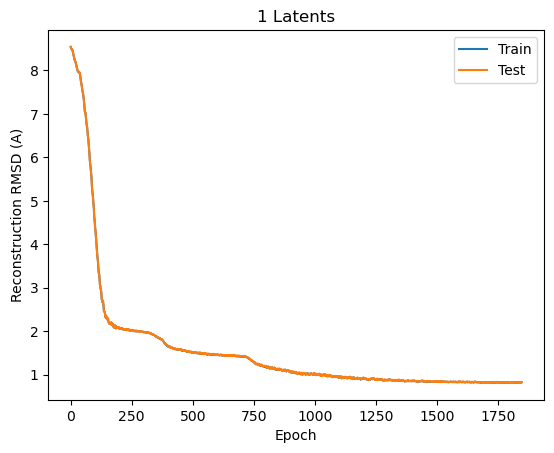

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 139, 128, 115, 101, 86, 68, 48, 26, 2]
    latents = 2
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 2 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 2 model was 0:37:00.746361 averaging 0:00:01.442980 per epoch


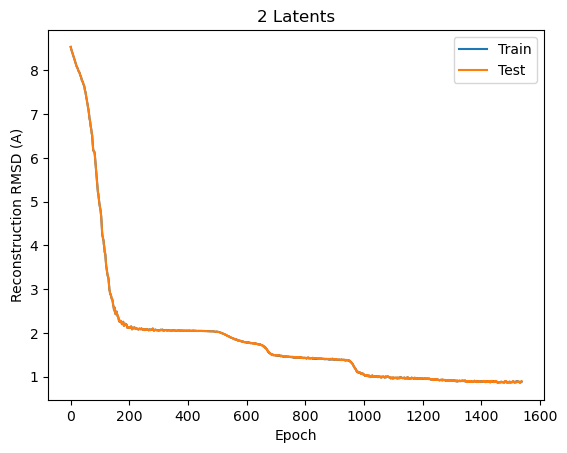

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 139, 128, 116, 102, 86, 68, 49, 27, 3]
    latents = 3
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 3 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 3 model was 0:34:53.546862 averaging 0:00:01.432955 per epoch


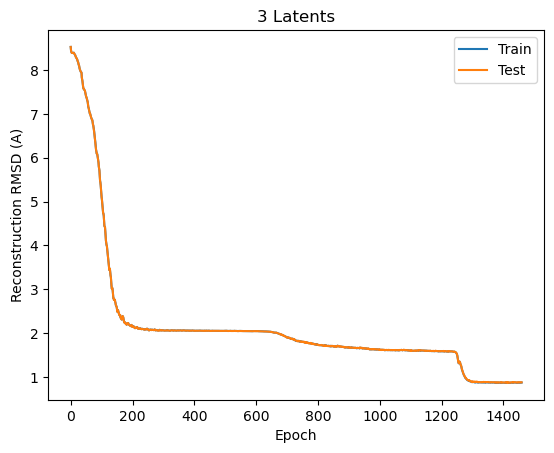

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 128, 116, 102, 86, 69, 50, 28, 4]
    latents = 4
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 4 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 4 model was 0:34:57.108298 averaging 0:00:01.447280 per epoch


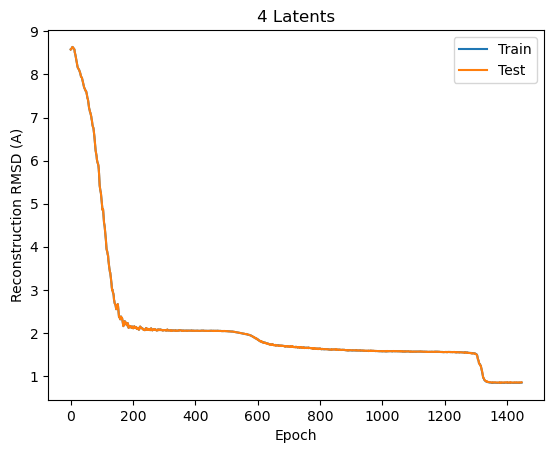

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 129, 116, 102, 87, 70, 50, 29, 5]
    latents = 5
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 5 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 5 model was 0:38:01.678030 averaging 0:00:01.419837 per epoch


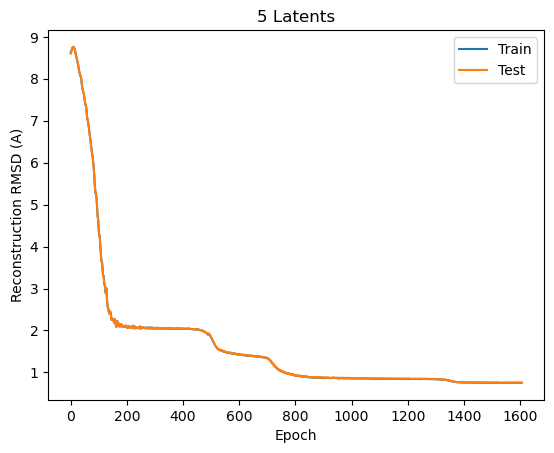

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 129, 117, 103, 88, 71, 52, 30, 7]
    latents = 7
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 7 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 7 model was 0:16:06.112384 averaging 0:00:01.452801 per epoch


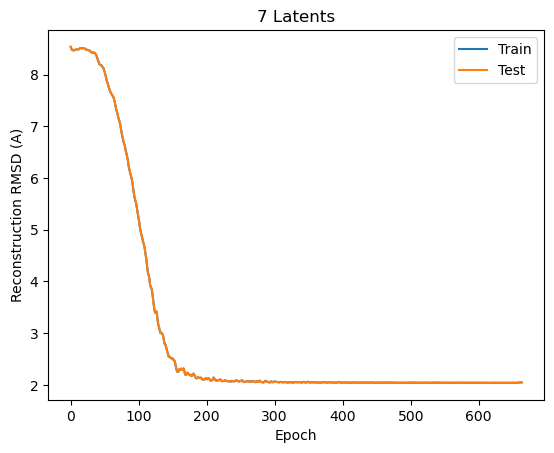

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 129, 117, 103, 88, 71, 52, 31, 8]
    latents = 8
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 8 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 8 model was 0:39:51.716527 averaging 0:00:01.408549 per epoch


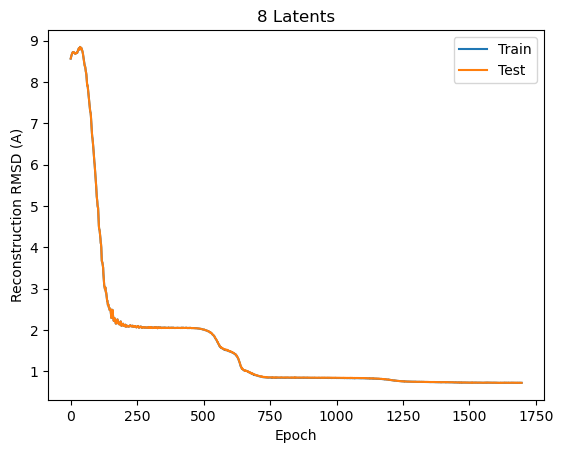

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 129, 117, 104, 89, 73, 54, 34, 11]
    latents = 11
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 11 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 11 model was 0:10:45.572318 averaging 0:00:01.518994 per epoch


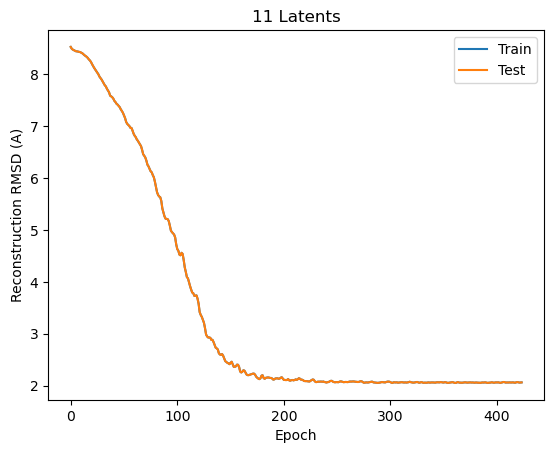

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 130, 118, 105, 90, 74, 56, 35, 13]
    latents = 13
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 13 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 13 model was 1:42:01.398095 averaging 0:00:01.442365 per epoch


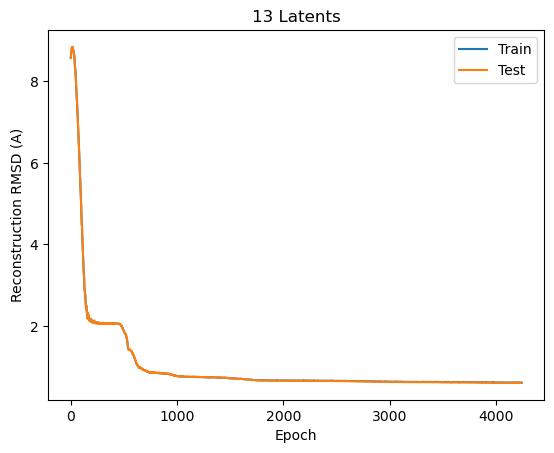

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 130, 119, 106, 92, 76, 58, 38, 16]
    latents = 16
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 16 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 16 model was 1:12:21.915091 averaging 0:00:01.448754 per epoch


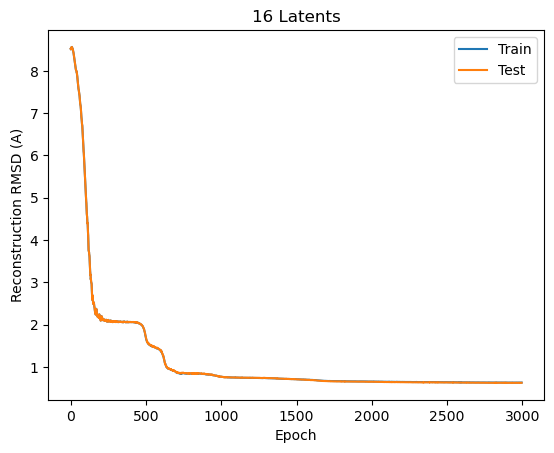

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 140, 130, 119, 106, 92, 76, 58, 39, 17]
    latents = 17
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 17 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 17 model was 2:00:02.102515 averaging 0:00:01.426724 per epoch


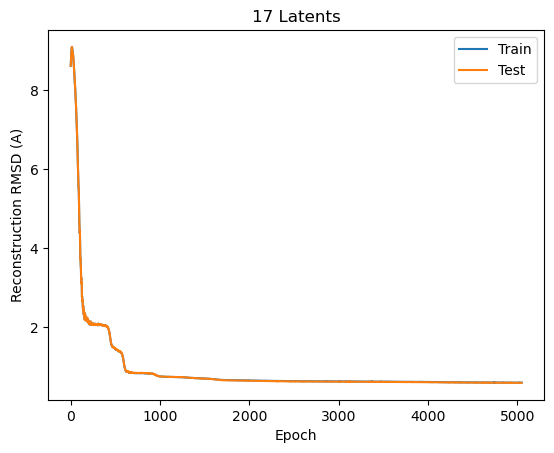

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 141, 131, 119, 107, 93, 77, 60, 40, 19]
    latents = 19
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 19 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 19 model was 0:11:24.848110 averaging 0:00:01.542451 per epoch


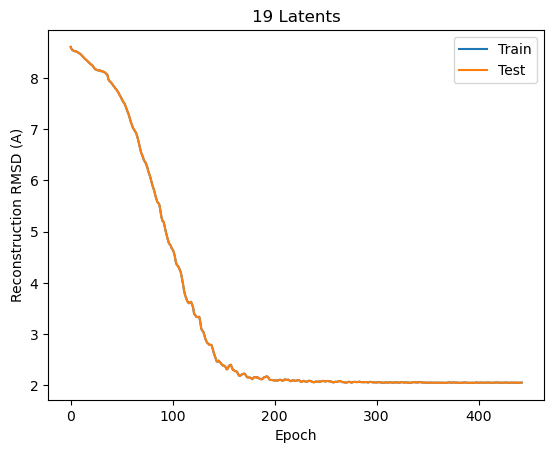

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 141, 131, 120, 108, 95, 79, 63, 44, 23]
    latents = 23
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 23 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 23 model was 0:09:42.627328 averaging 0:00:01.549541 per epoch


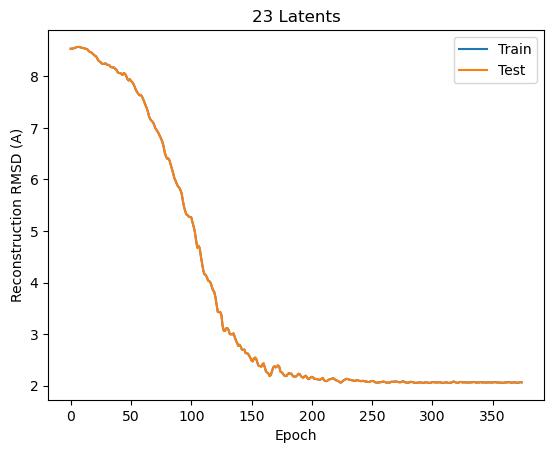

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 141, 132, 122, 110, 97, 83, 67, 49, 28]
    latents = 29
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 29 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 29 model was 0:10:14.406109 averaging 0:00:01.571371 per epoch


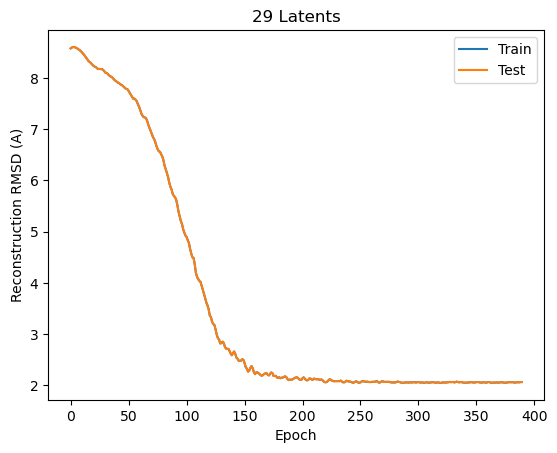

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 141, 132, 122, 111, 98, 84, 68, 50, 31]
    latents = 31
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 31 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 31 model was 0:10:35.754344 averaging 0:00:01.546848 per epoch


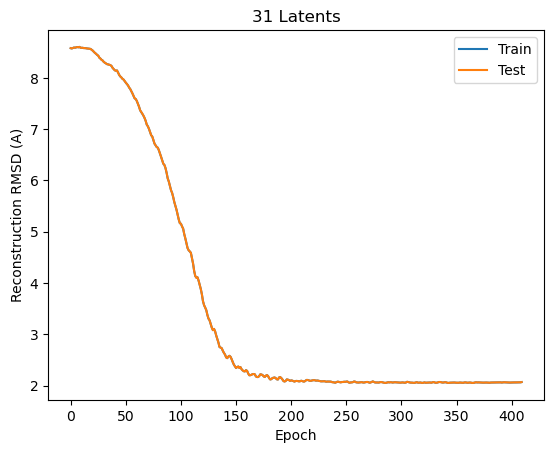

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 141, 132, 122, 111, 98, 84, 69, 51, 32]
    latents = 32
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 32 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 32 model was 1:55:20.071231 averaging 0:00:01.461781 per epoch


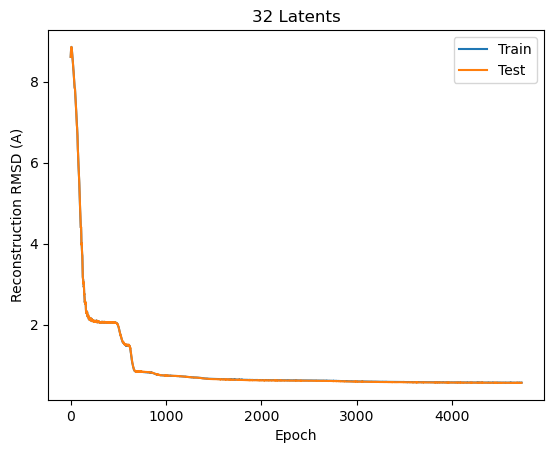

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 142, 133, 123, 113, 101, 87, 72, 55, 37]
    latents = 37
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 37 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 37 model was 0:12:17.731106 averaging 0:00:01.566308 per epoch


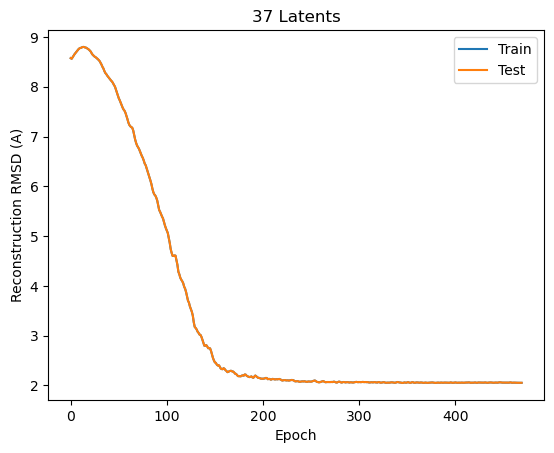

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 142, 134, 124, 114, 102, 89, 75, 59, 41]
    latents = 41
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 41 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 41 model was 1:59:31.798402 averaging 0:00:01.469932 per epoch


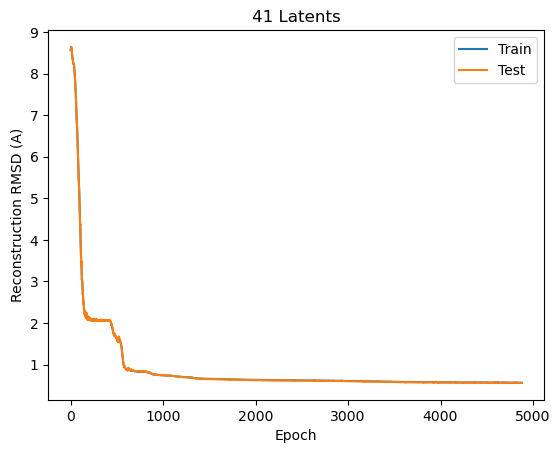

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 142, 134, 125, 115, 103, 90, 76, 60, 42]
    latents = 43
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 43 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 43 model was 0:14:25.180853 averaging 0:00:01.525892 per epoch


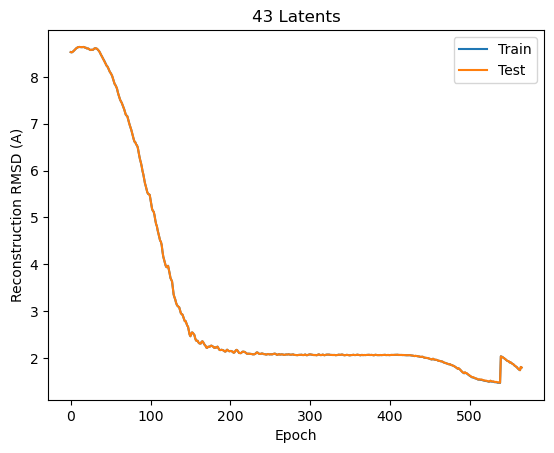

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 142, 135, 126, 116, 105, 93, 79, 64, 47]
    latents = 47
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 47 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 47 model was 0:18:45.451296 averaging 0:00:01.504614 per epoch


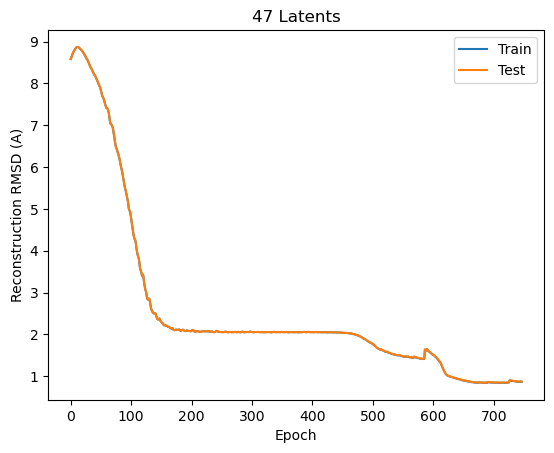

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 143, 135, 127, 118, 108, 96, 83, 69, 53]
    latents = 53
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 53 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 53 model was 1:38:23.986798 averaging 0:00:01.459937 per epoch


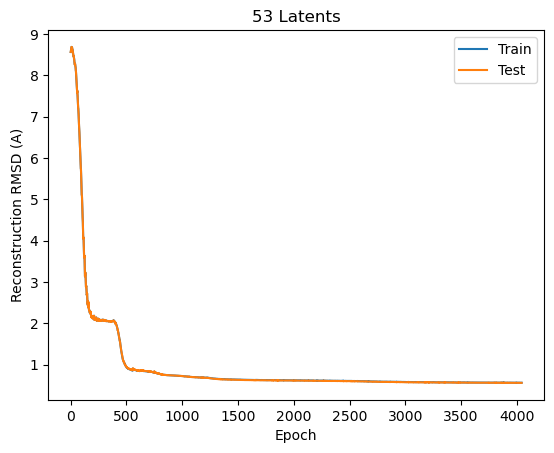

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 143, 136, 129, 120, 110, 99, 87, 74, 59]
    latents = 59
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 59 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 59 model was 0:19:05.824705 averaging 0:00:01.519661 per epoch


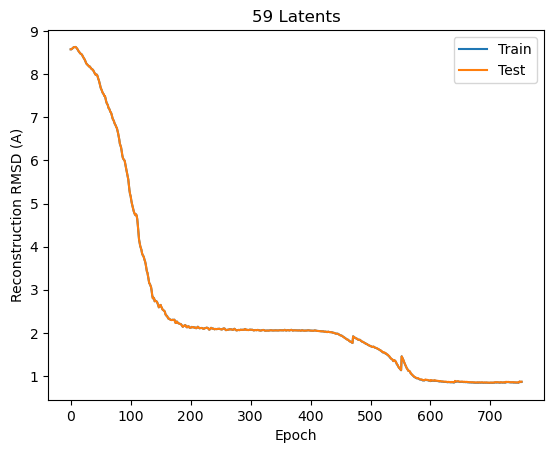

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 143, 137, 129, 121, 111, 100, 89, 75, 61]
    latents = 61
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 61 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 61 model was 2:00:17.384973 averaging 0:00:01.470835 per epoch


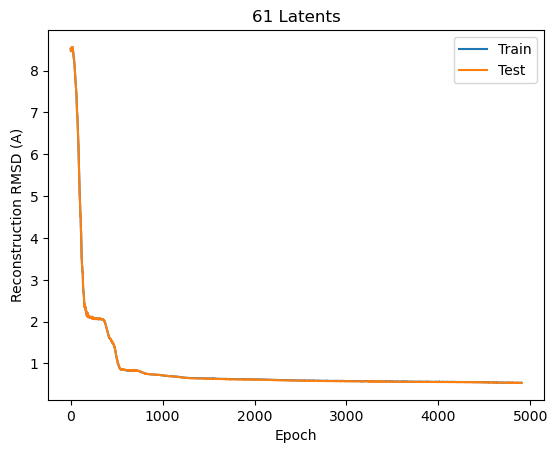

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 144, 137, 130, 121, 112, 102, 91, 78, 64]
    latents = 64
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 64 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 64 model was 1:08:31.727431 averaging 0:00:01.472154 per epoch


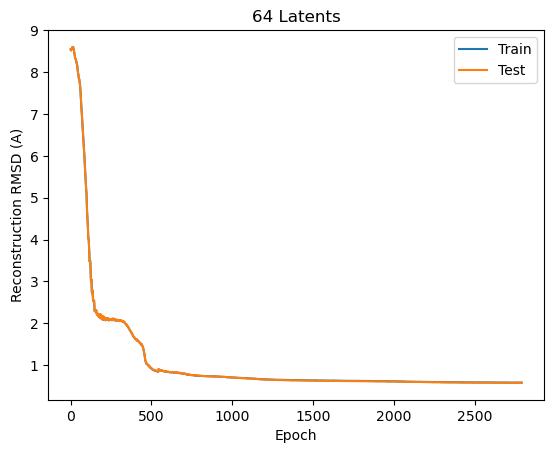

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 144, 137, 130, 122, 114, 104, 93, 80, 67]
    latents = 67
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 67 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 67 model was 1:38:01.311289 averaging 0:00:01.449313 per epoch


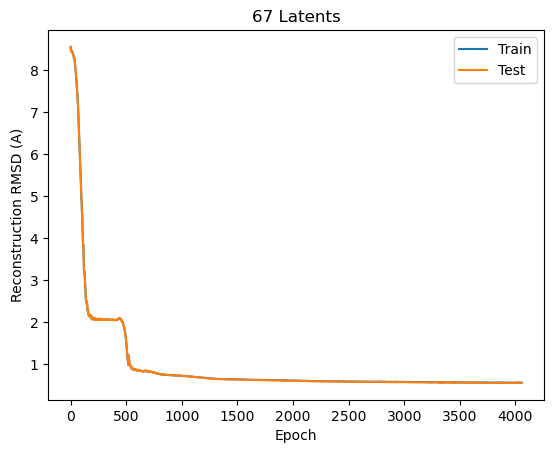

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 144, 138, 131, 124, 115, 106, 95, 84, 71]
    latents = 71
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 71 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 71 model was 1:30:18.102872 averaging 0:00:01.472311 per epoch


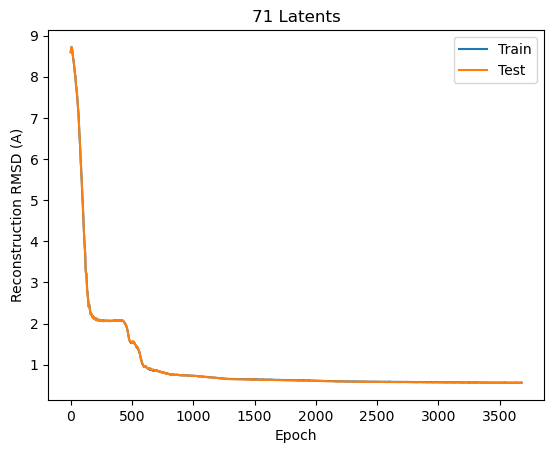

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 144, 138, 132, 124, 116, 107, 97, 85, 73]
    latents = 73
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 73 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 73 model was 2:08:42.333878 averaging 0:00:01.492815 per epoch


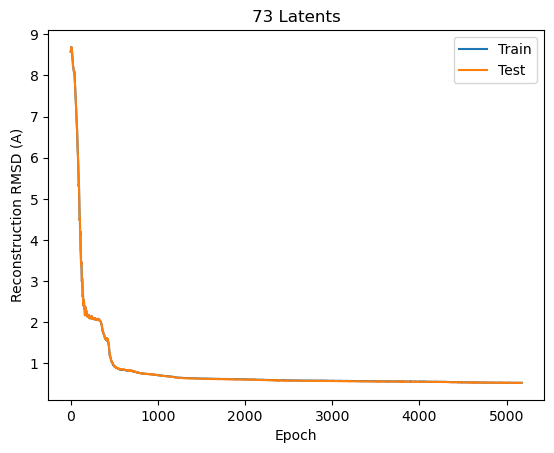

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 145, 139, 133, 126, 119, 110, 101, 90, 79]
    latents = 79
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 79 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 79 model was 2:23:07.735068 averaging 0:00:01.472015 per epoch


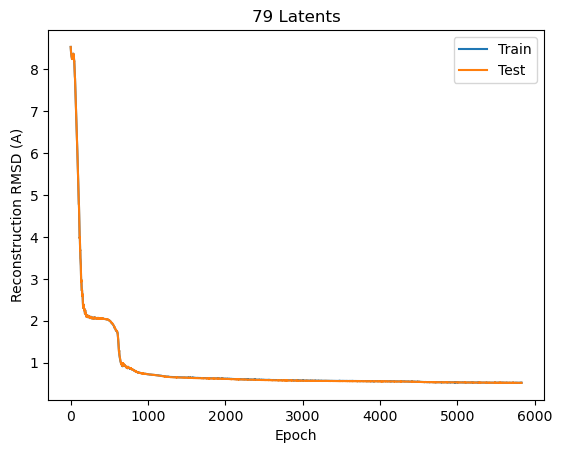

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 145, 140, 134, 128, 121, 113, 104, 94, 83]
    latents = 83
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 83 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 83 model was 2:30:38.533886 averaging 0:00:01.536121 per epoch


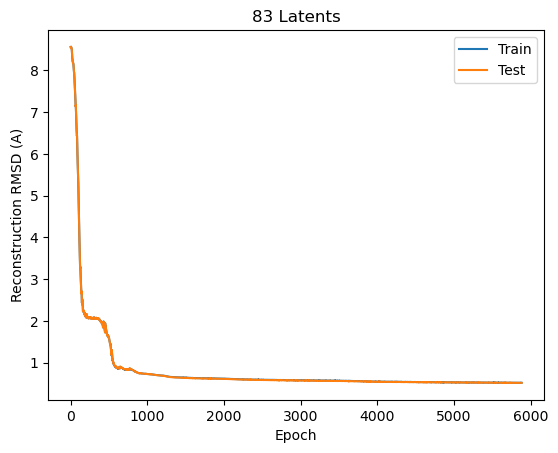

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 145, 141, 135, 130, 123, 116, 108, 99, 89]
    latents = 89
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 89 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 89 model was 1:44:54.058501 averaging 0:00:01.496803 per epoch


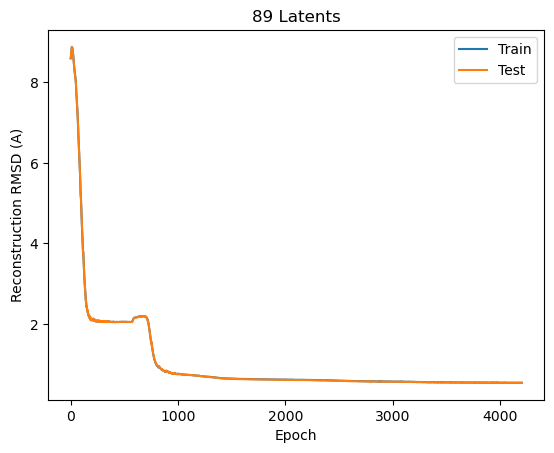

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 146, 142, 137, 132, 127, 120, 113, 105, 97]
    latents = 97
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 97 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 97 model was 1:18:23.745806 averaging 0:00:01.512458 per epoch


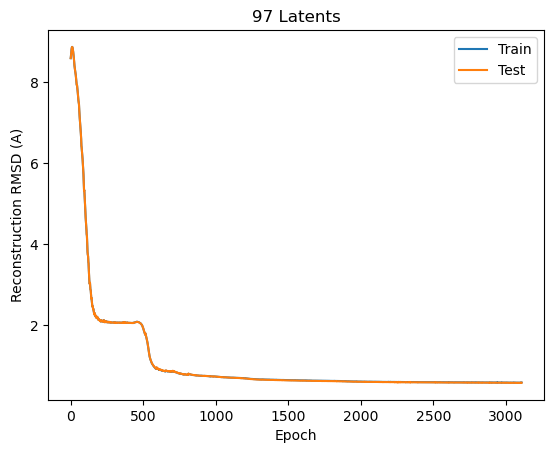

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 146, 142, 138, 134, 128, 122, 116, 109, 101]
    latents = 101
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 101 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 101 model was 2:12:55.656196 averaging 0:00:01.514557 per epoch


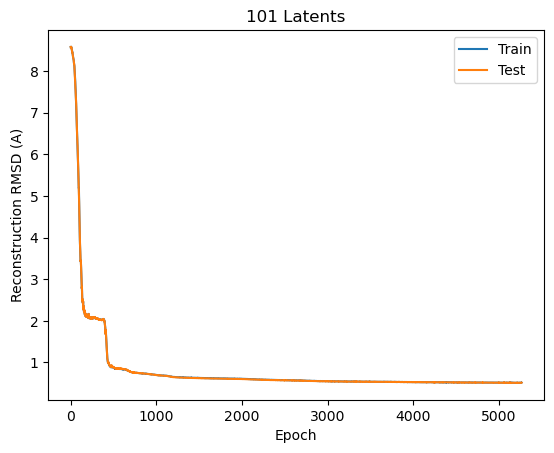

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 146, 143, 139, 134, 129, 124, 117, 110, 103]
    latents = 103
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 103 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 103 model was 2:03:34.603674 averaging 0:00:01.481143 per epoch


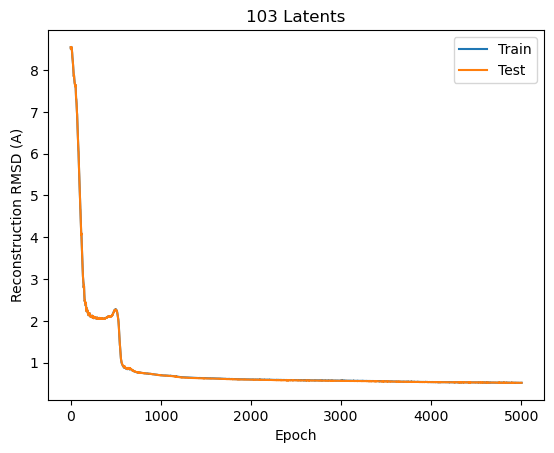

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 147, 143, 140, 135, 131, 126, 120, 114, 107]
    latents = 107
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 107 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 107 model was 1:55:20.254571 averaging 0:00:01.486309 per epoch


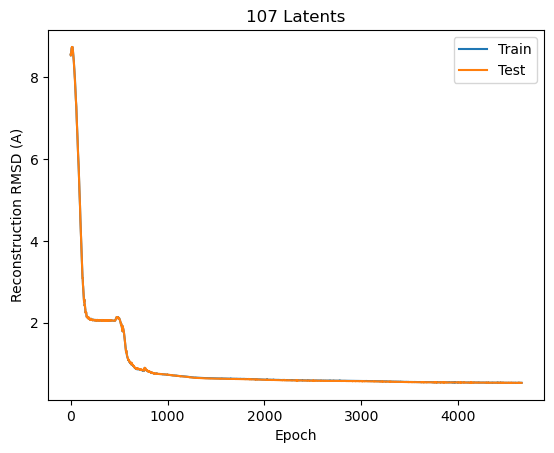

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 147, 144, 140, 136, 132, 127, 121, 115, 109]
    latents = 109
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 109 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 109 model was 1:33:45.514023 averaging 0:00:01.498140 per epoch


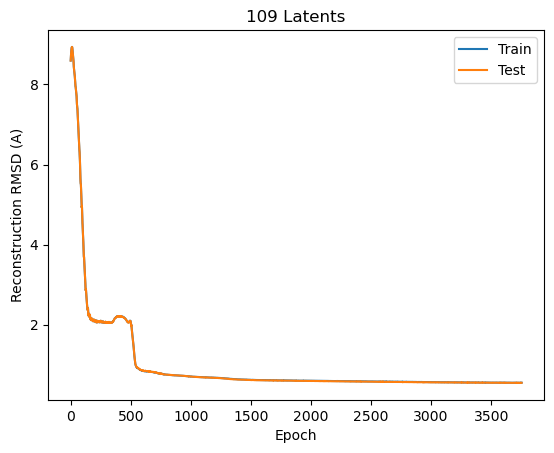

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 147, 144, 141, 137, 134, 129, 124, 119, 113]
    latents = 113
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 113 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 113 model was 2:18:02.953625 averaging 0:00:01.478571 per epoch


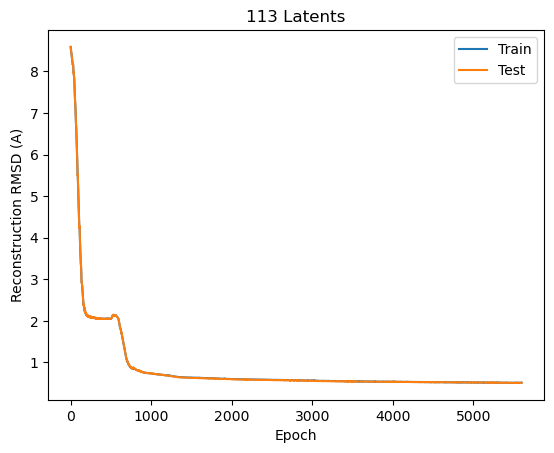

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 148, 146, 144, 142, 140, 137, 134, 130, 127]
    latents = 127
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 127 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 127 model was 0:59:35.778589 averaging 0:00:01.490529 per epoch


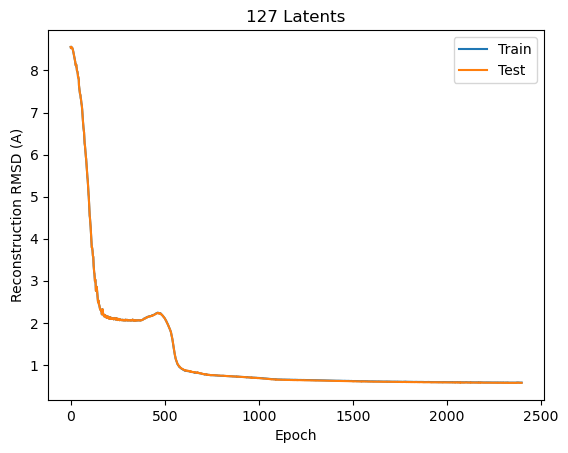

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 148, 146, 144, 142, 140, 137, 134, 131, 128]
    latents = 128
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 128 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 128 model was 1:57:15.272711 averaging 0:00:01.450572 per epoch


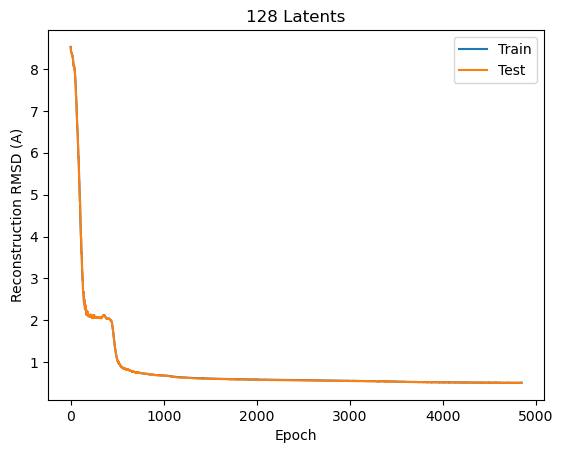

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 148, 147, 145, 143, 141, 139, 136, 134, 131]
    latents = 131
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 131 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 131 model was 1:43:52.080902 averaging 0:00:01.483123 per epoch


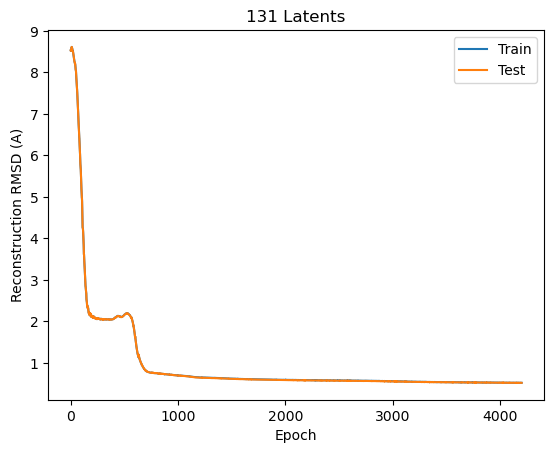

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 149, 148, 147, 145, 144, 142, 141, 139, 137]
    latents = 137
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 137 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 137 model was 1:51:00.201770 averaging 0:00:01.517822 per epoch


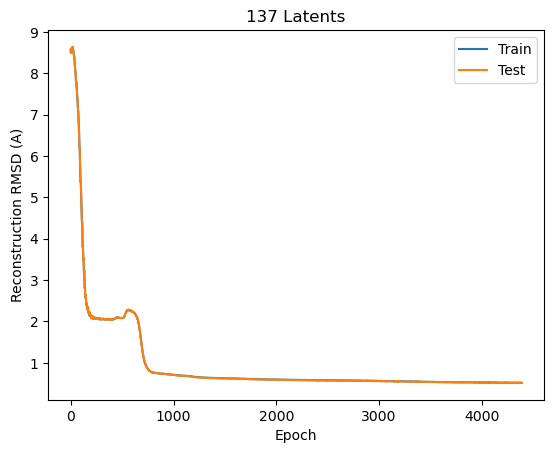

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 149, 148, 147, 146, 145, 143, 142, 140, 139]
    latents = 139
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 139 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 139 model was 1:38:53.220564 averaging 0:00:01.513191 per epoch


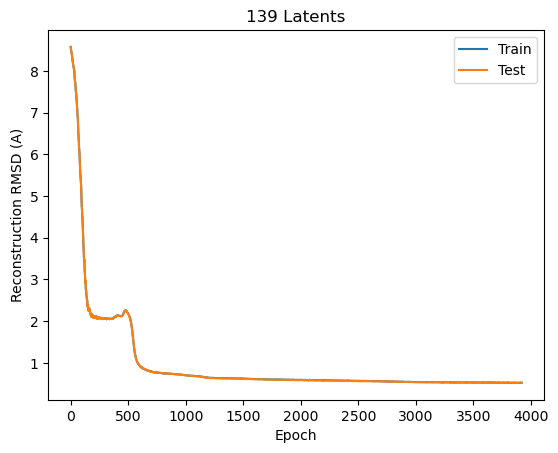

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 149, 149, 149, 149, 149, 149, 149, 149, 149]
    latents = 149
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 149 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 149 model was 1:40:41.855707 averaging 0:00:01.502949 per epoch


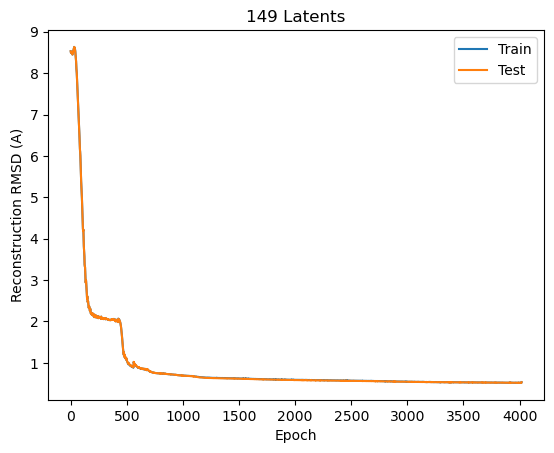

Load Files
Establish Directories
Load Data with MDTraj
Batch data
(8000, 150) (2000, 150)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model BatchNorm_VAE(
    # attributes
    input_size = 150
    hidden_layers = [150, 150, 150, 150, 150, 150, 150, 150, 150, 150]
    latents = 150
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
INITIALIZATION COMPLETE for 150 Latents, 1.0 Scale
RMSD Lowest Run - Break Reason - Test Set Loss Increasing
Time to train 150 model was 1:48:13.783997 averaging 0:00:01.458949 per epoch


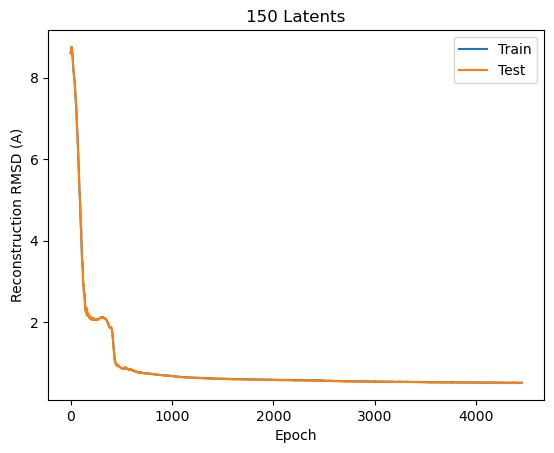

In [4]:
from datetime import datetime

for latent_n in latent_nums(150):
    start = datetime.now()
    json_params['latent_dim'] = latent_n
    self = NN_Experiment(json_params, from_json_params=True)
    n_rmsd = 100 + 10*latent_n
    self.MAIN_train_rmsd_only_wo_reporting_potential(n_rmsd=n_rmsd, verbose=False)
    train_time = datetime.now() - start
    
    print(f"Time to train {self.n_latents} model was {train_time} averaging {train_time/self.epoch} per epoch") 

    traingrp = self.rootgrp['Train']
    testgrp = self.rootgrp['Test']
    train_data = np.mean(traingrp['RMSD'][:-1, :], axis=1)
    test_data = np.mean(testgrp['RMSD'][:-1, :], axis=1)
    
    plt.clf()
    _ = plt.plot(np.arange(len(train_data)), train_data*10, label='Train')
    _ = plt.plot(np.arange(len(test_data)), test_data*10, label='Test')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction RMSD (A)')
    title = f"{self.n_latents} Latents"
    plt.title(title)
    plt.savefig(f"{self.model_name}/figures/{title.replace(' ', '_')}.png", dpi=900)
    plt.show()

In [5]:
raise Exception('You Shall Not Pass!')

Exception: You Shall Not Pass!

In [6]:
import pyscripts.loss_rmsd_only as loss

In [7]:
root_key = jax.random.PRNGKey(self.epoch)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

In [8]:
decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                          'batch_stats':self.state.batch_stats},
                                                         self.test_data,
                                                         main_key,
                                                         train=False,
                                                         rngs={'params': params_key,
                                                               'dropout': dropout_key})

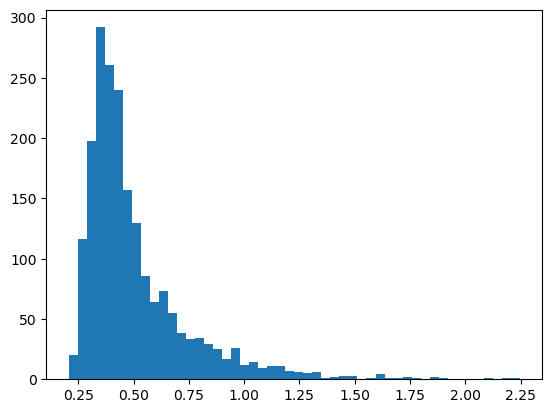

In [9]:
rmsd_vals = loss.atom_rmsd(self.test_data, decoded)*10
_ = plt.hist(rmsd_vals, bins=50)

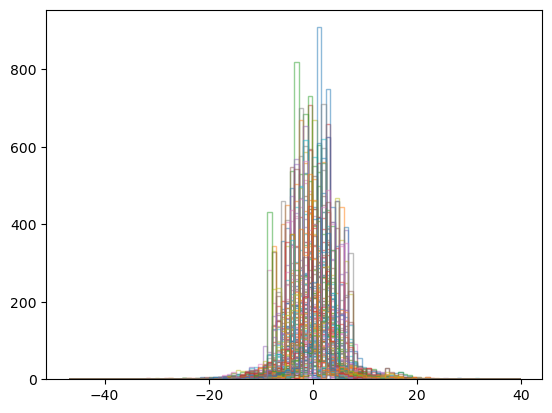

In [10]:
_ = plt.hist(latent_means, bins=100, histtype='step', alpha=0.5)

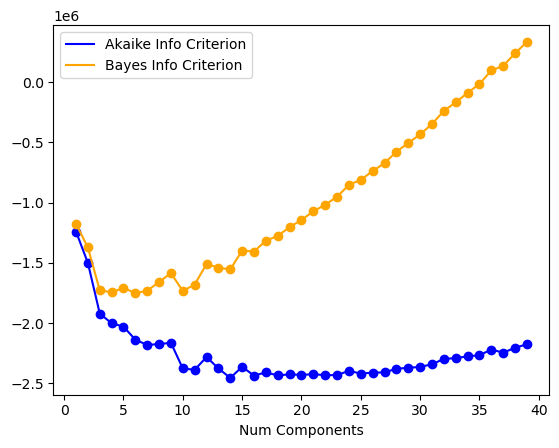

In [11]:
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import jensenshannon

decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                          'batch_stats':self.state.batch_stats},
                                                          self.test_data,
                                                          main_key,
                                                          train=False,
                                                          rngs={'params': params_key,
                                                                'dropout': dropout_key})

ics = []
for i in range(1, 40):
    MM = GaussianMixture(n_components=i).fit(latent_means)
    ics.append((i, MM.aic(latent_means), MM.bic(latent_means)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1], color='blue', label='Akaike Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 1], color='blue')
_ = plt.plot(ics[:, 0], ics[:, 2], color='orange', label='Bayes Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 2], color='orange')
plt.legend()
plt.xlabel('Num Components')
plt.show()

In [12]:
num_components = 14
MM = GaussianMixture(n_components=num_components).fit(latent_means)
samples, _ = MM.sample(latent_means.shape[0])

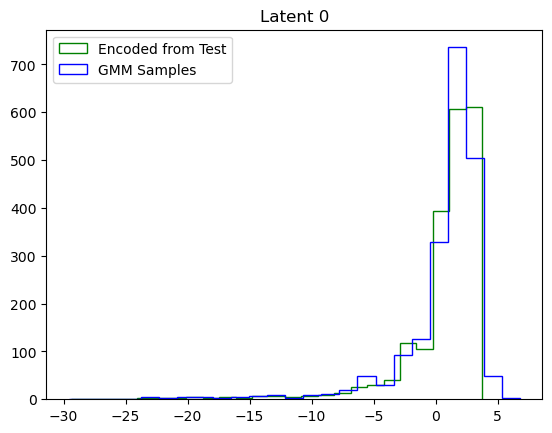

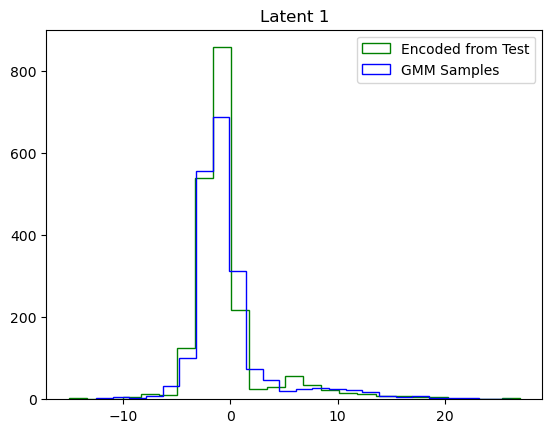

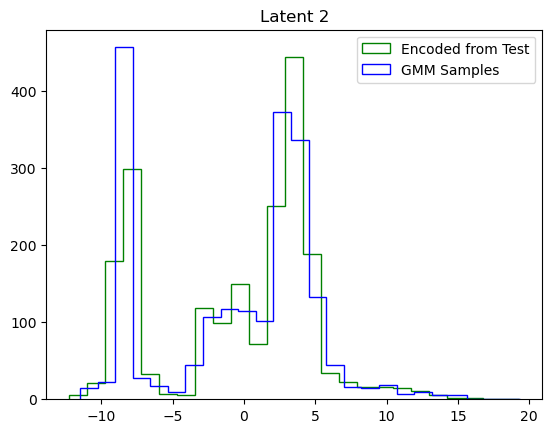

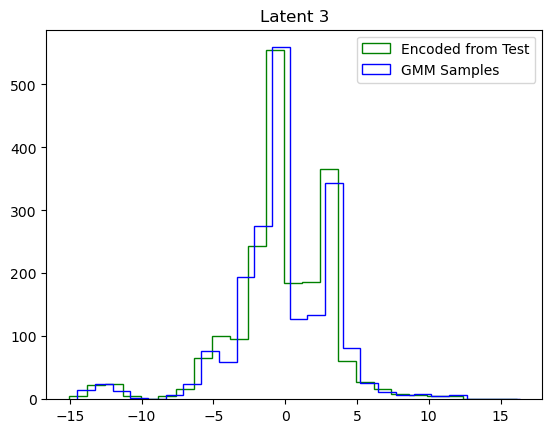

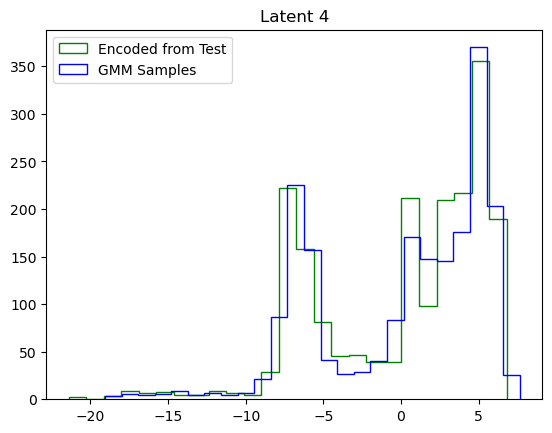

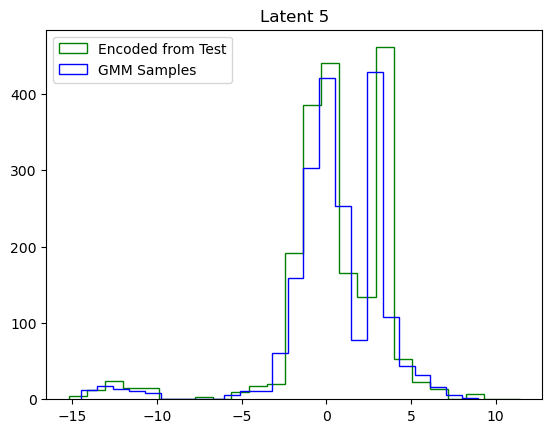

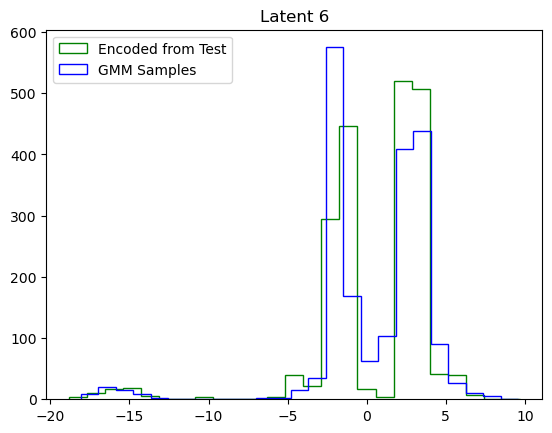

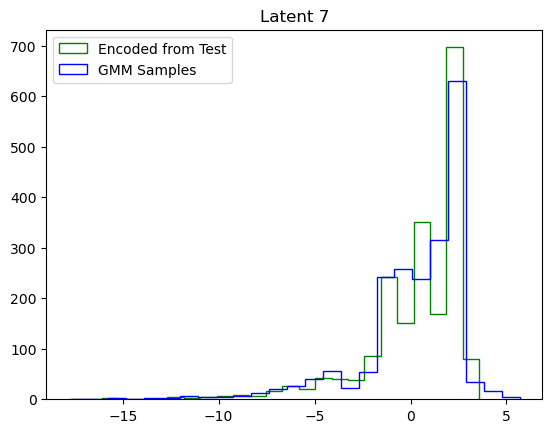

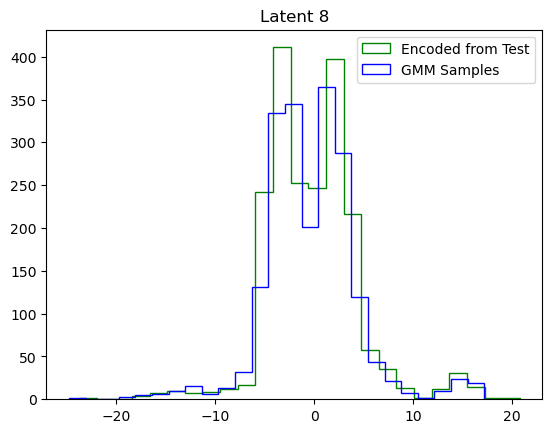

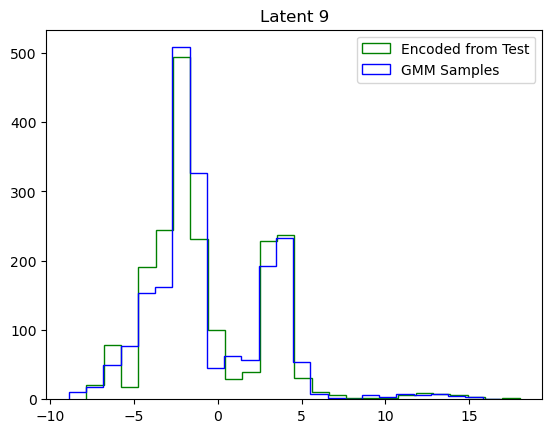

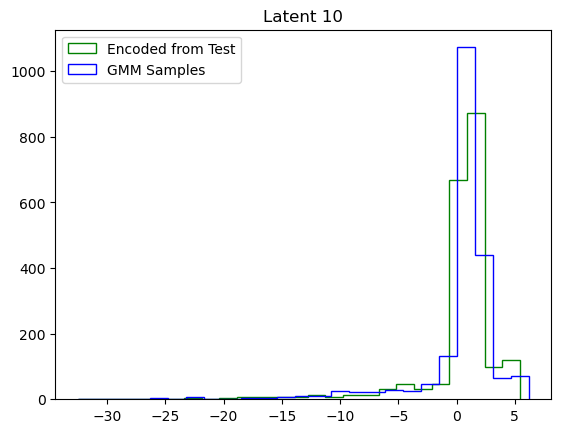

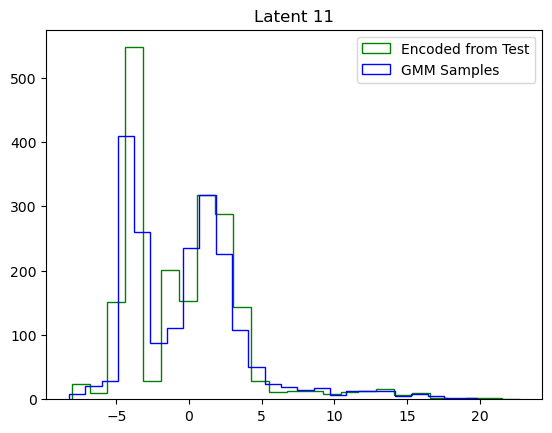

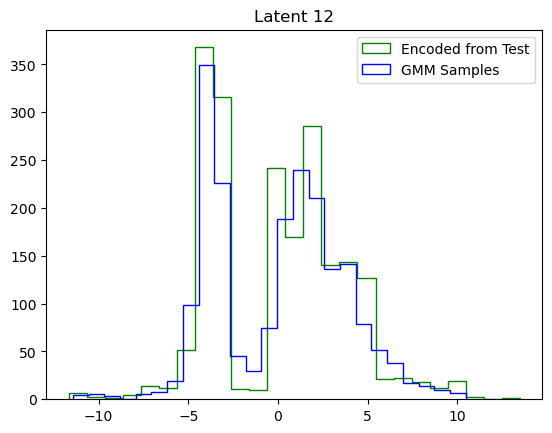

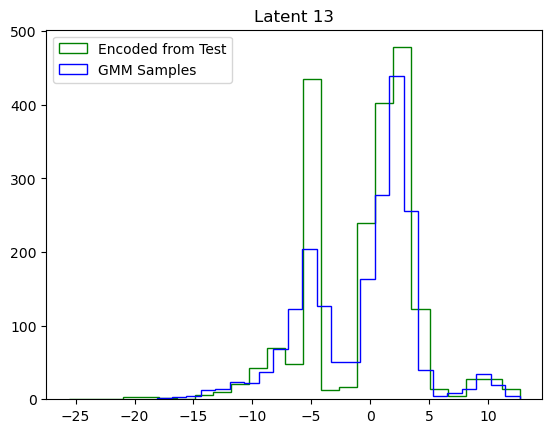

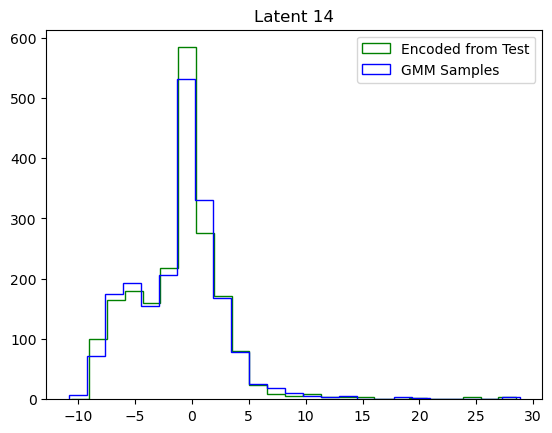

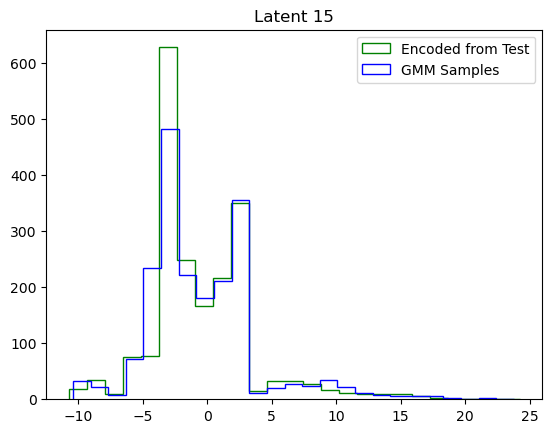

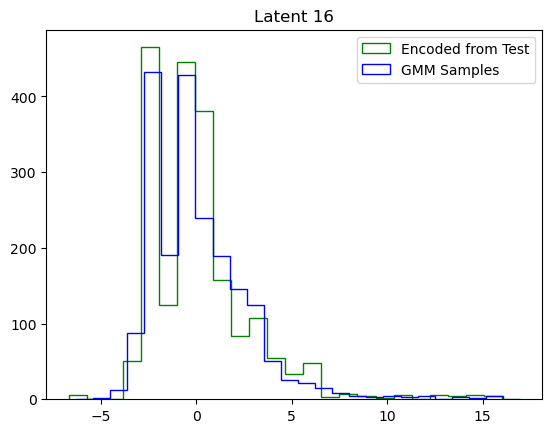

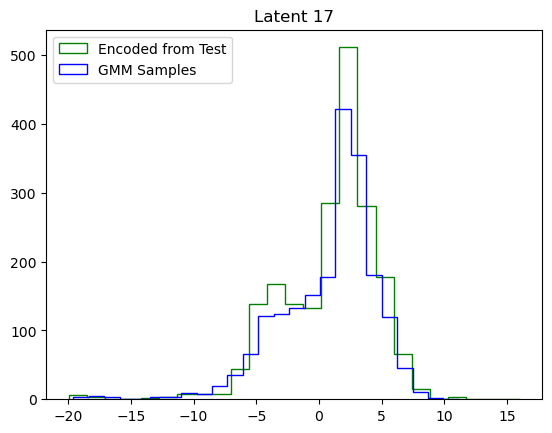

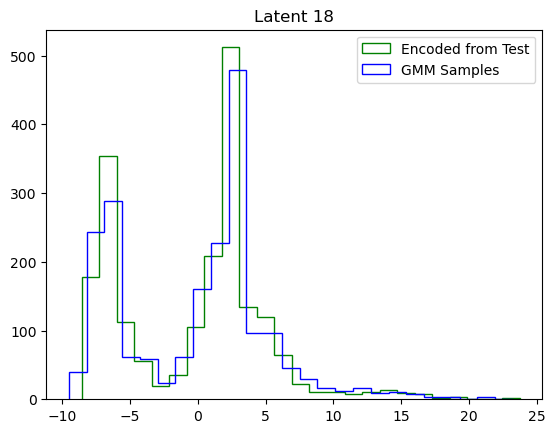

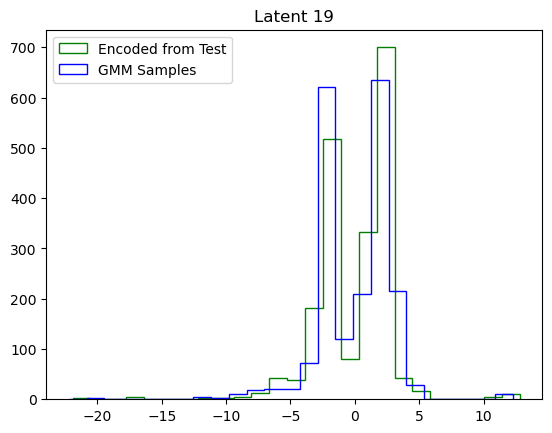

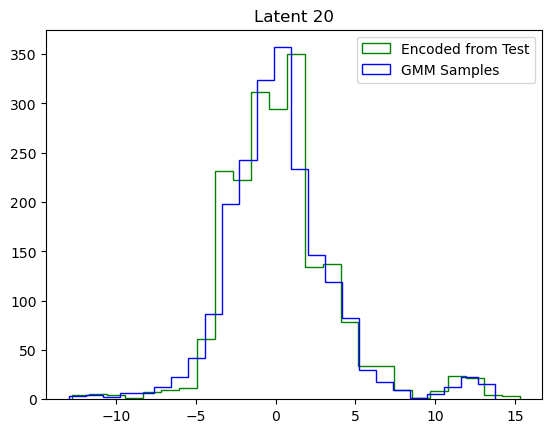

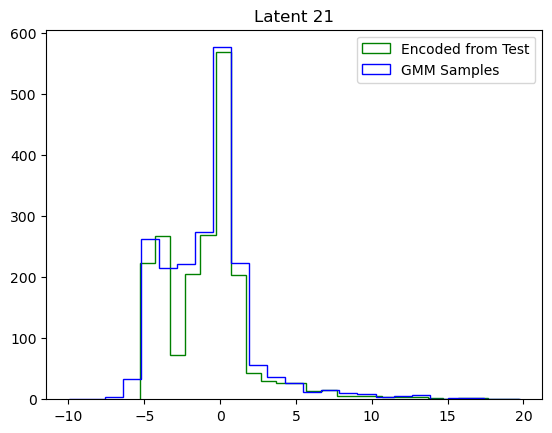

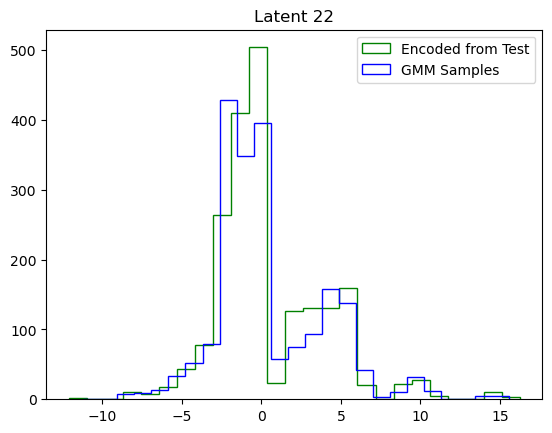

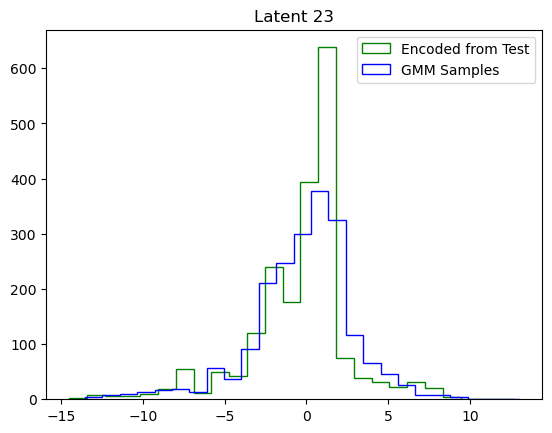

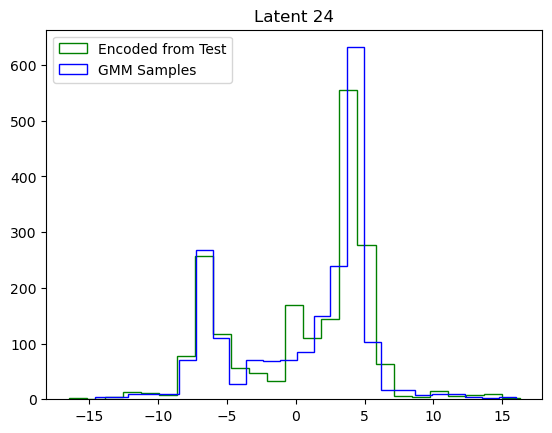

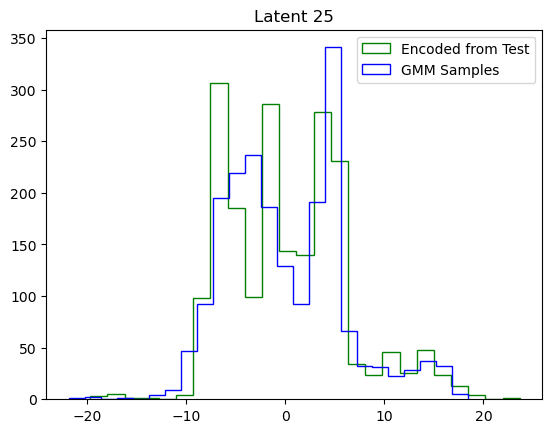

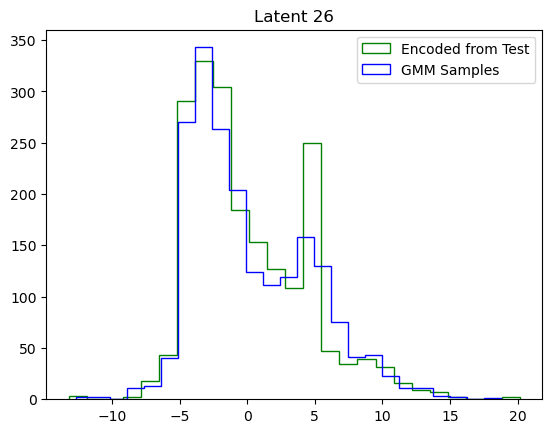

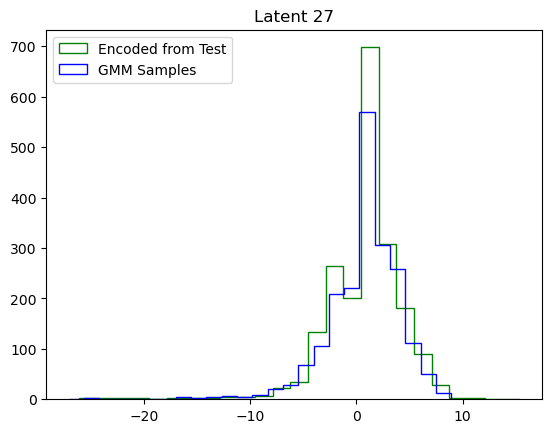

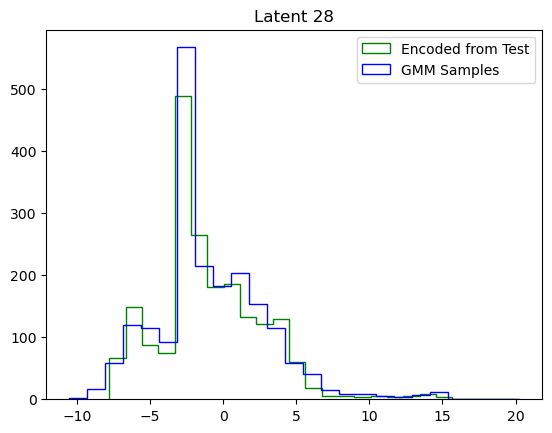

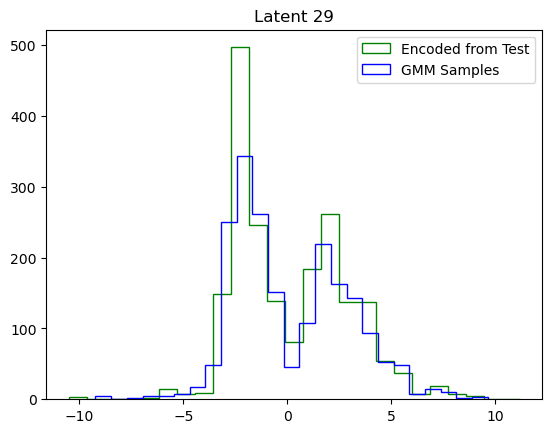

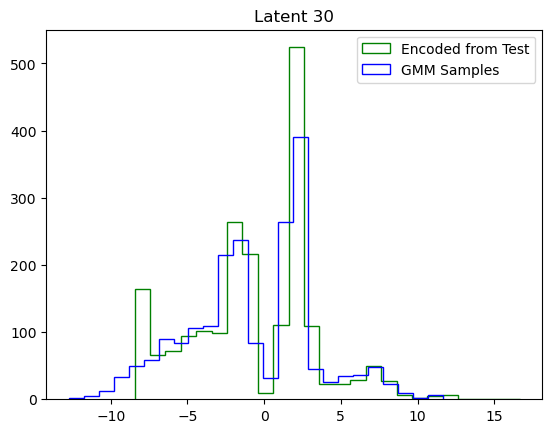

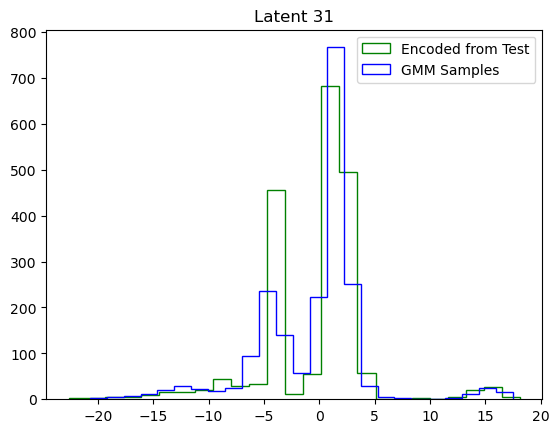

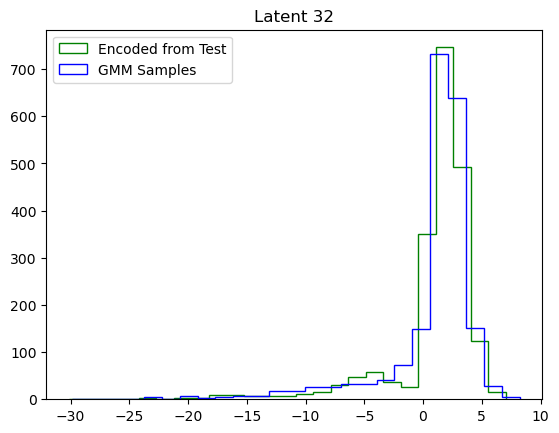

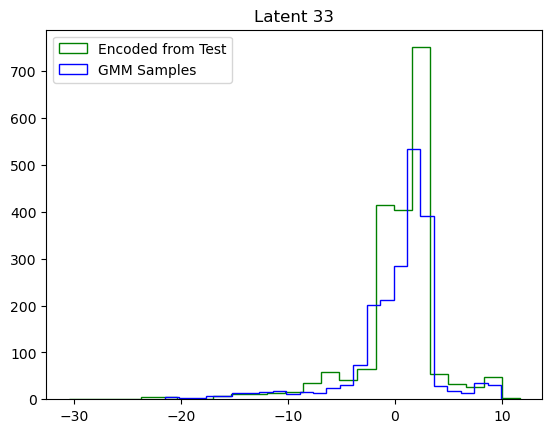

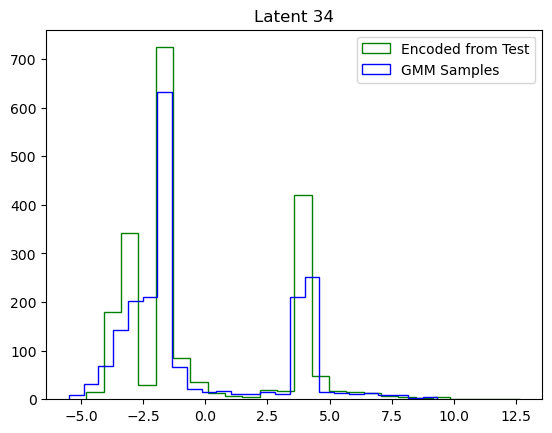

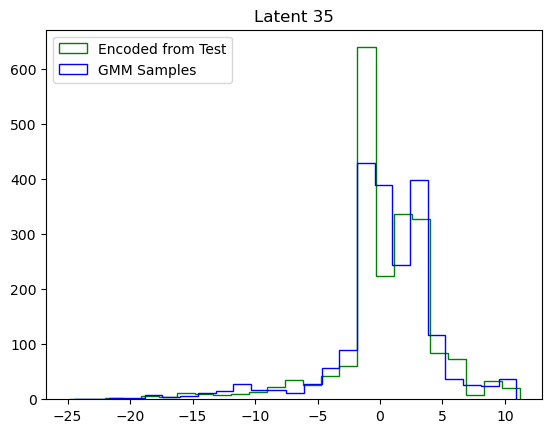

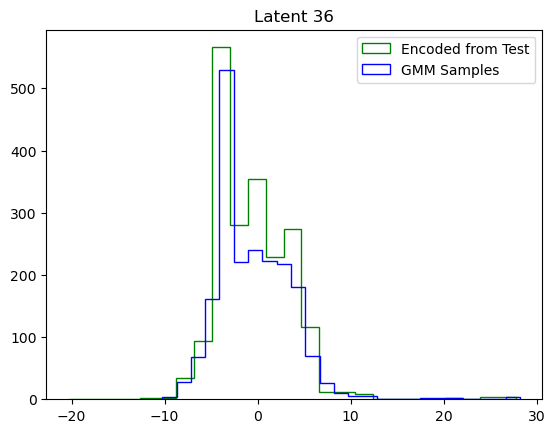

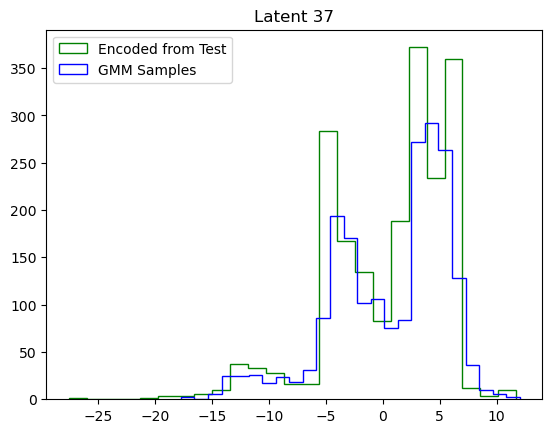

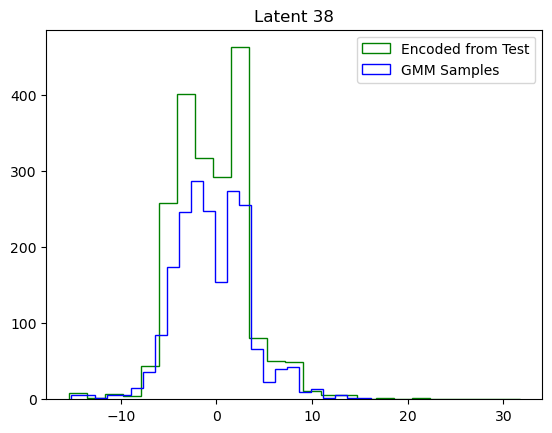

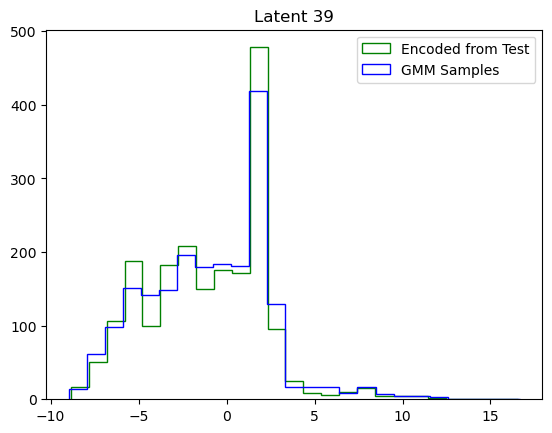

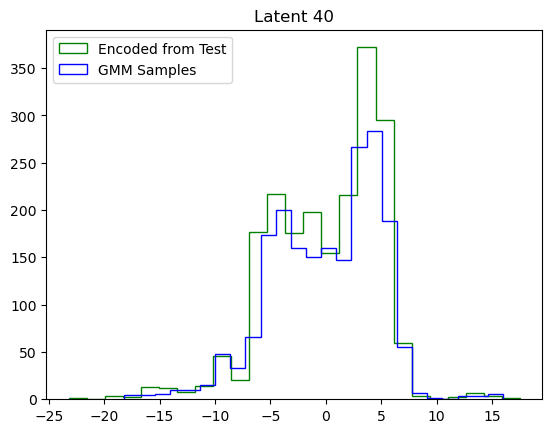

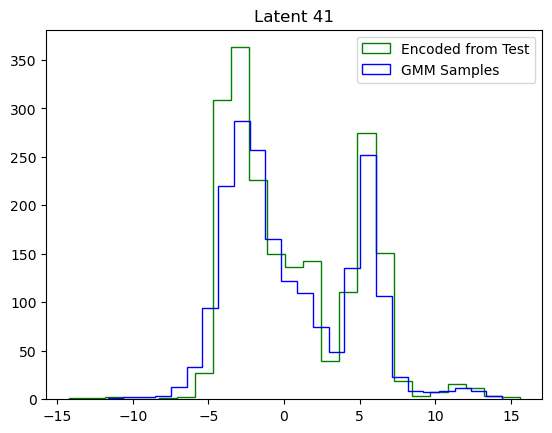

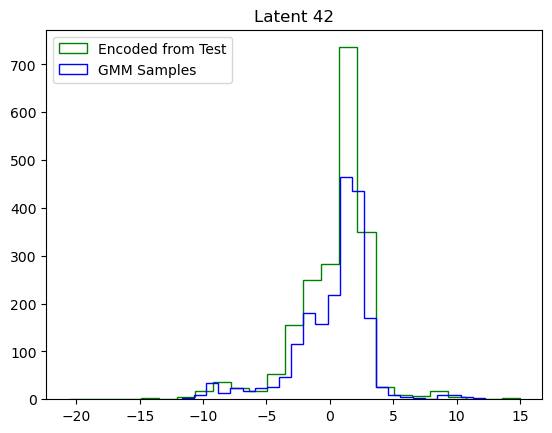

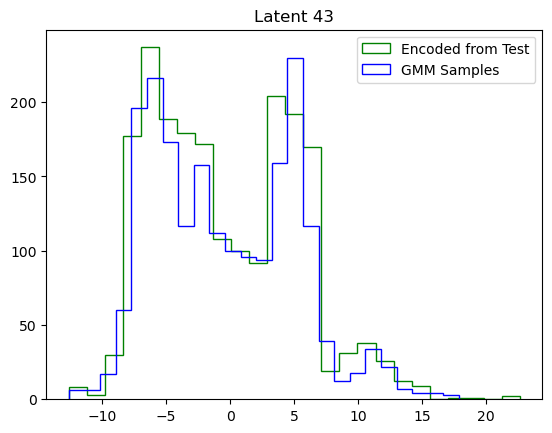

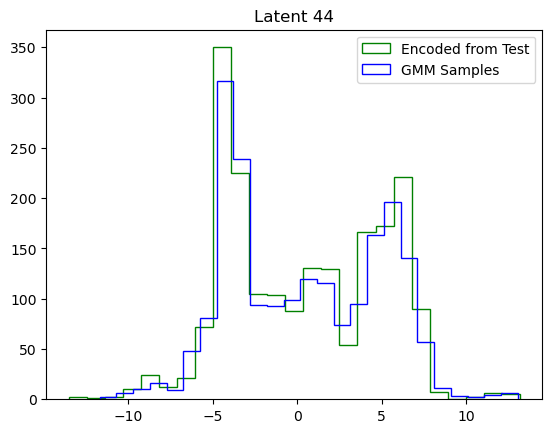

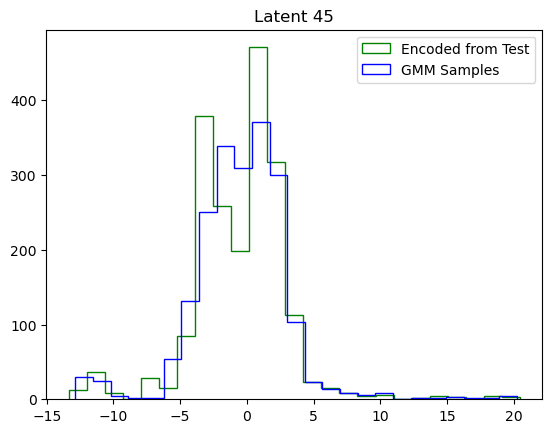

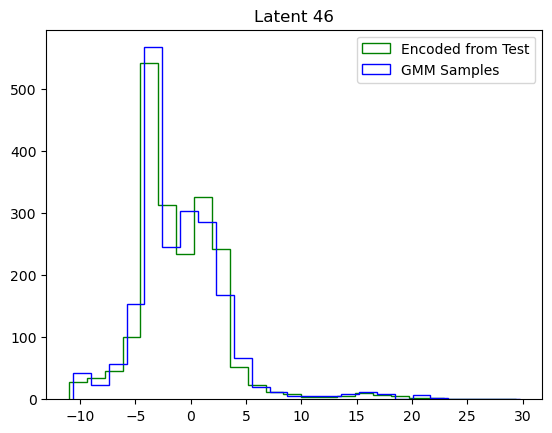

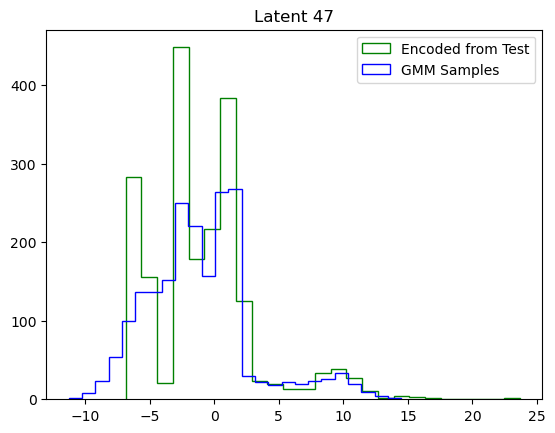

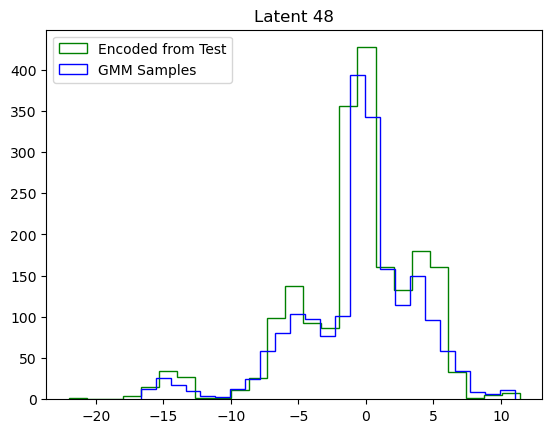

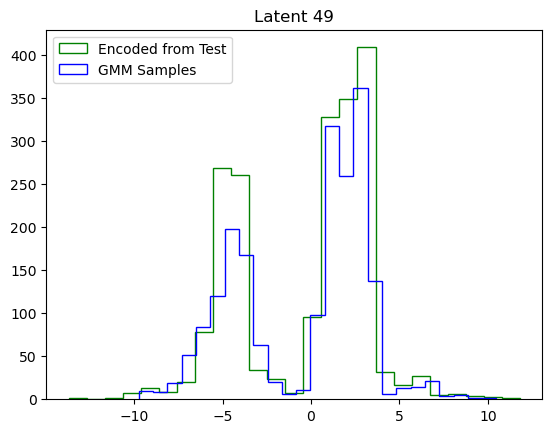

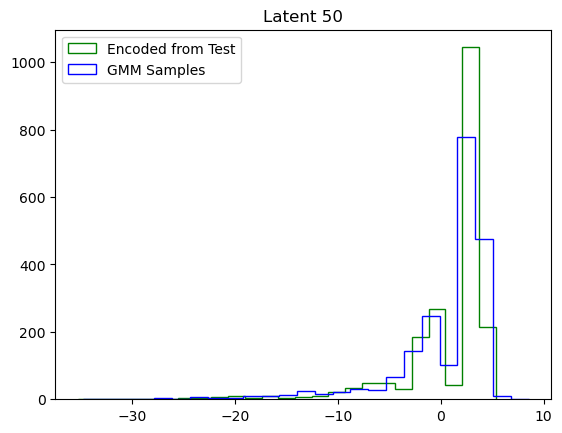

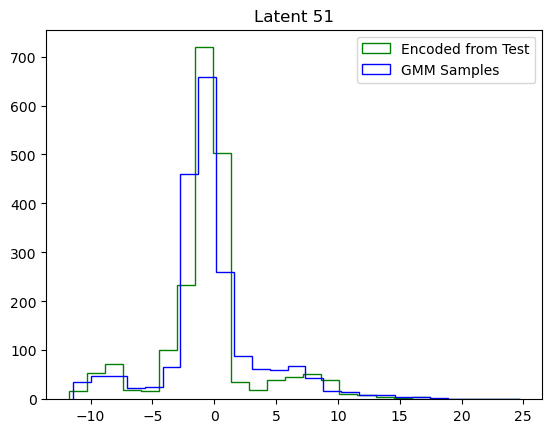

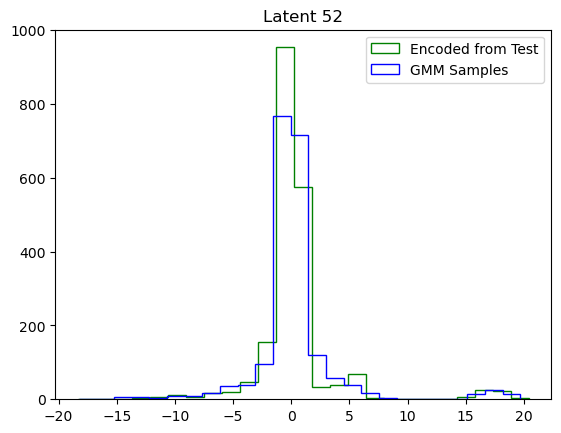

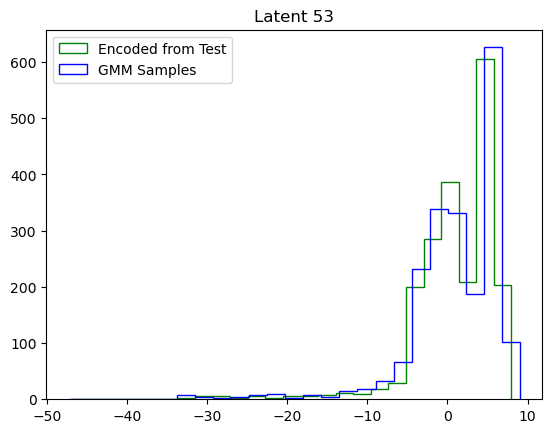

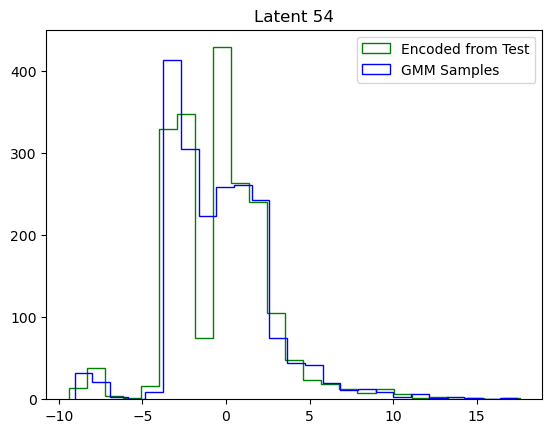

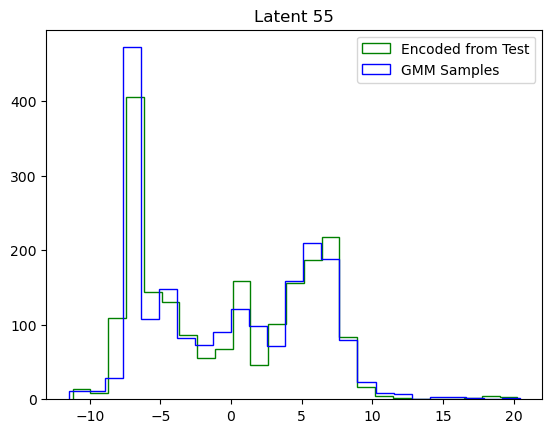

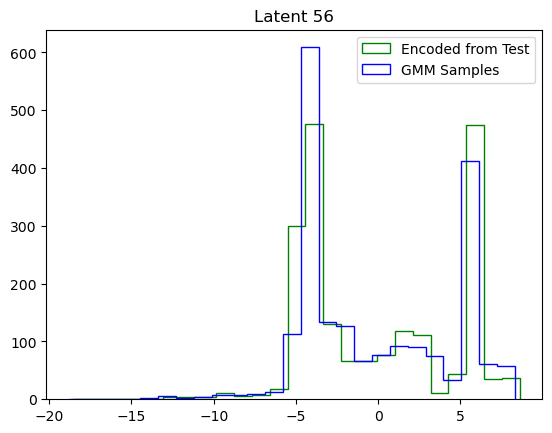

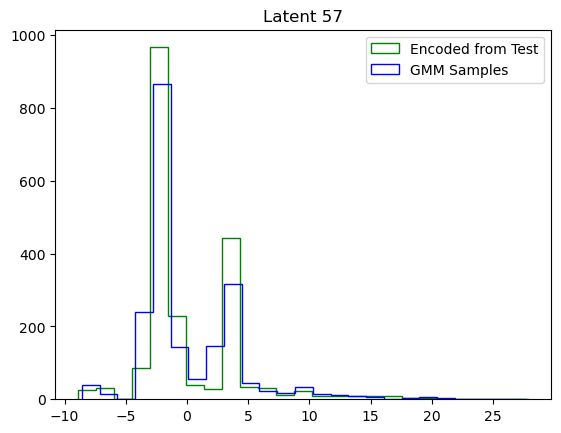

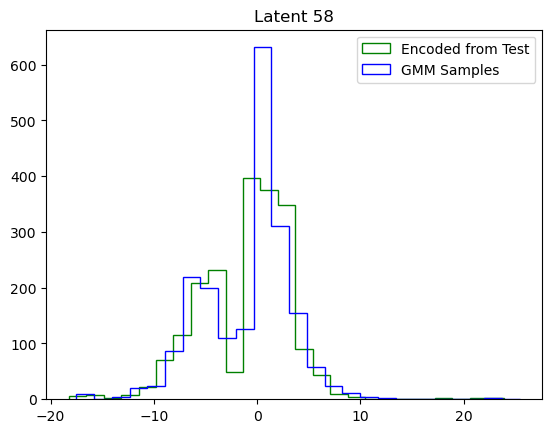

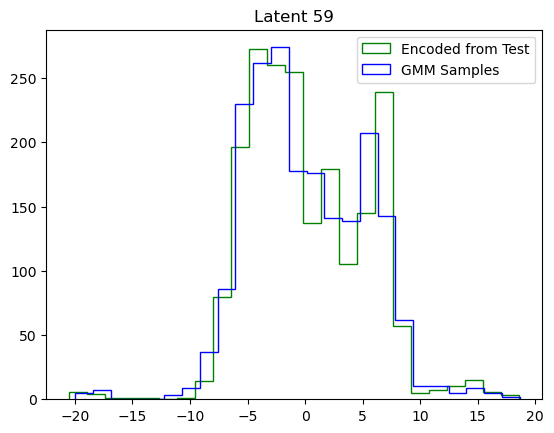

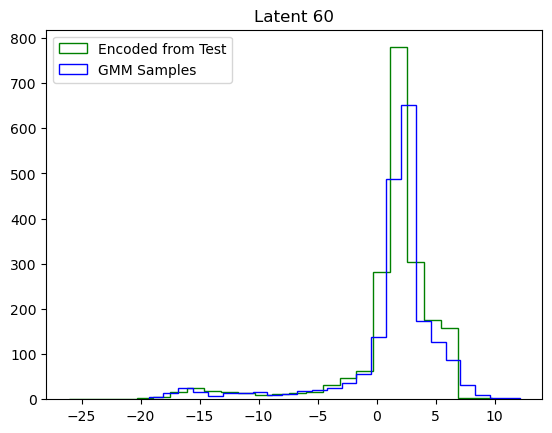

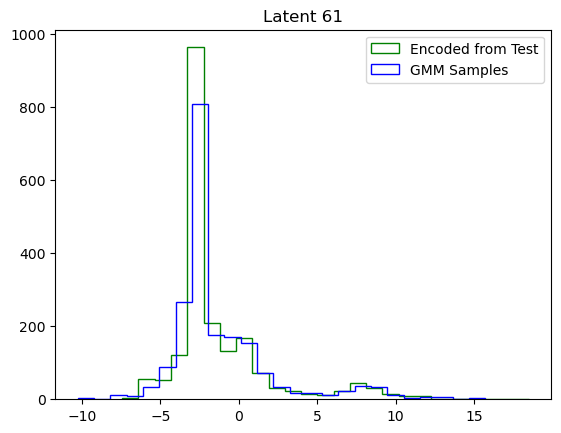

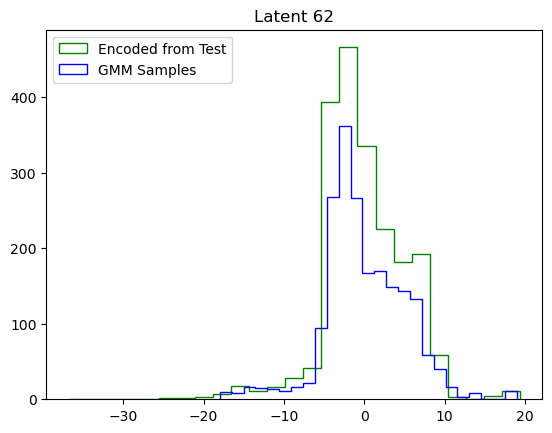

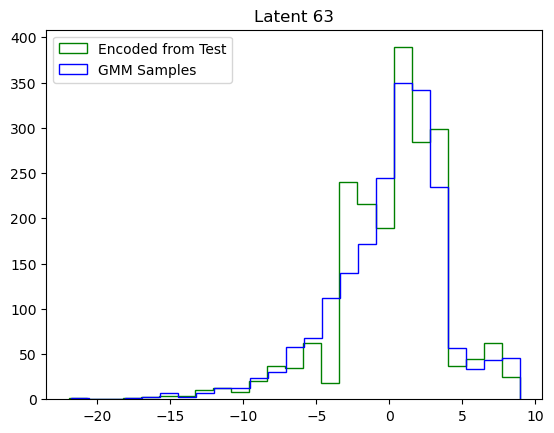

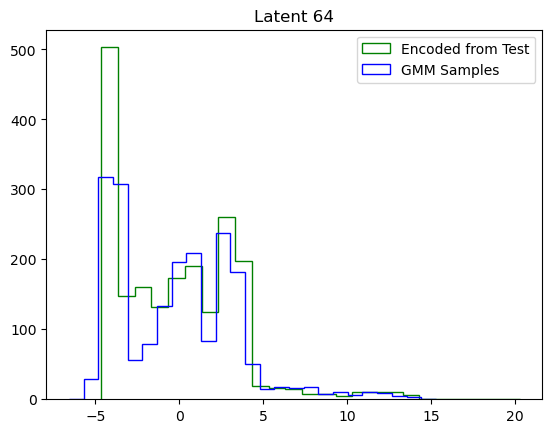

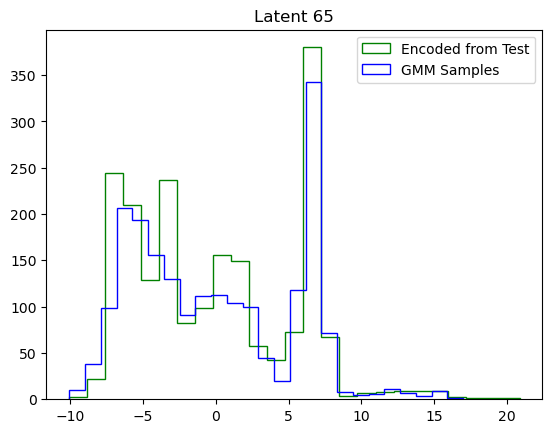

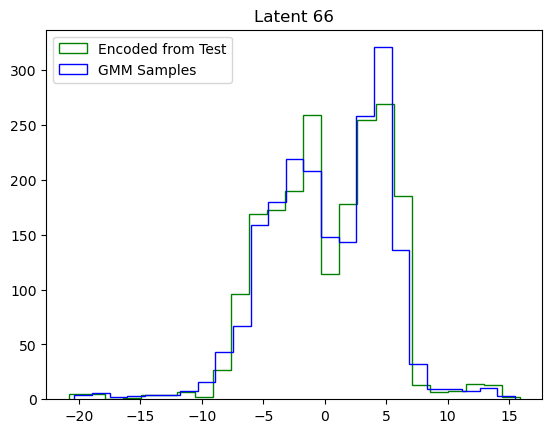

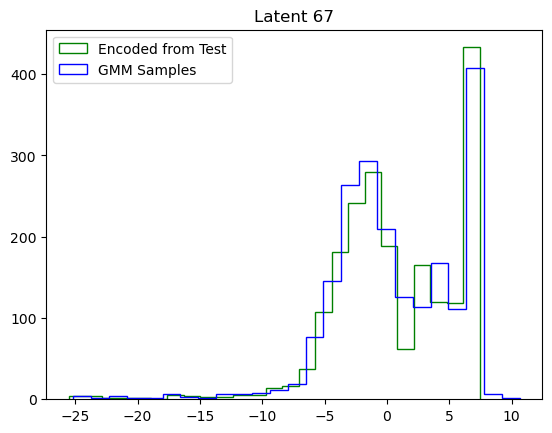

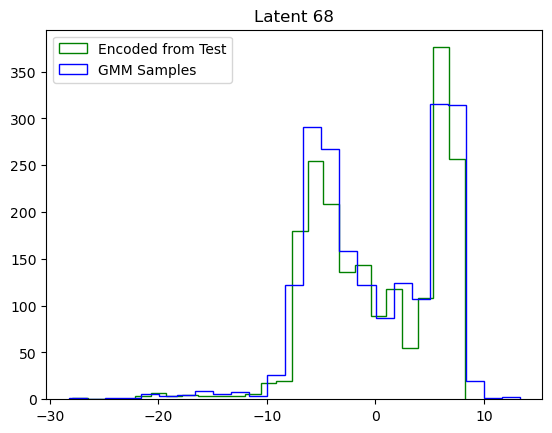

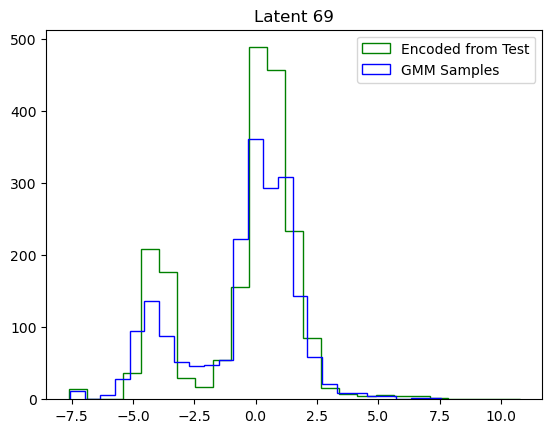

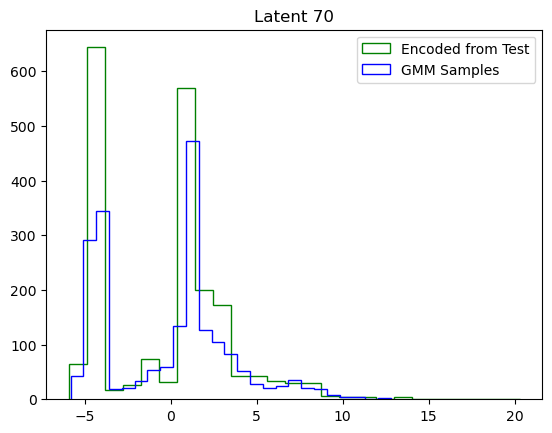

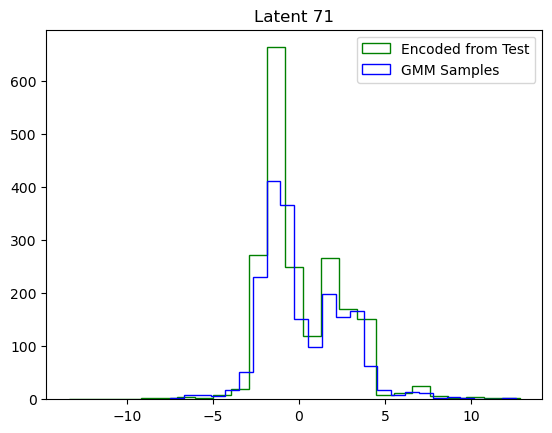

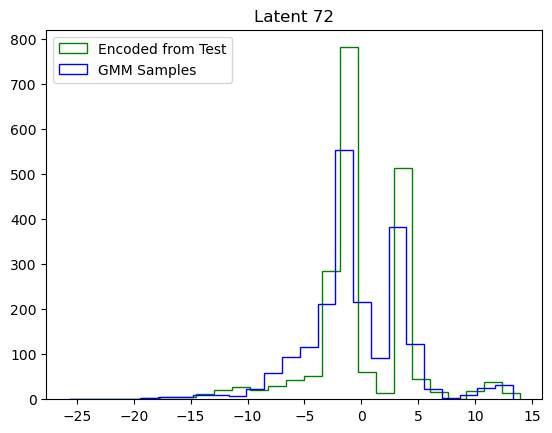

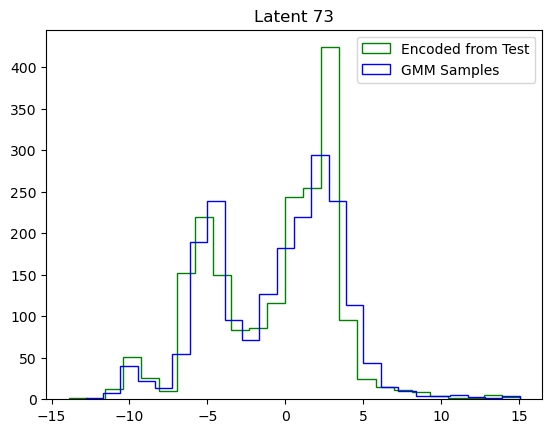

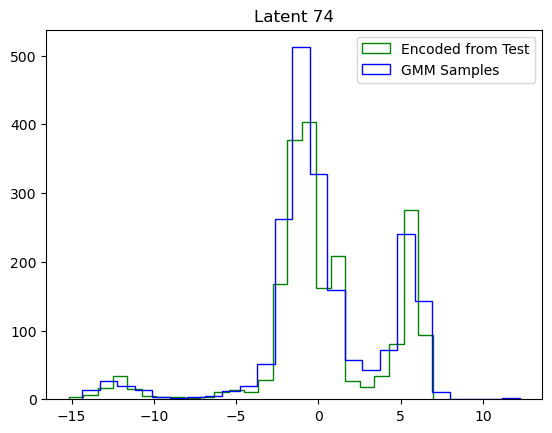

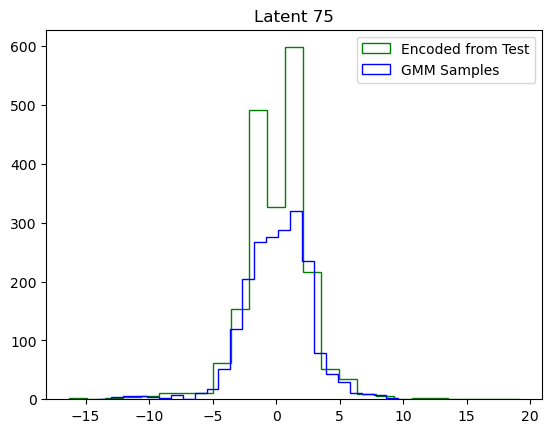

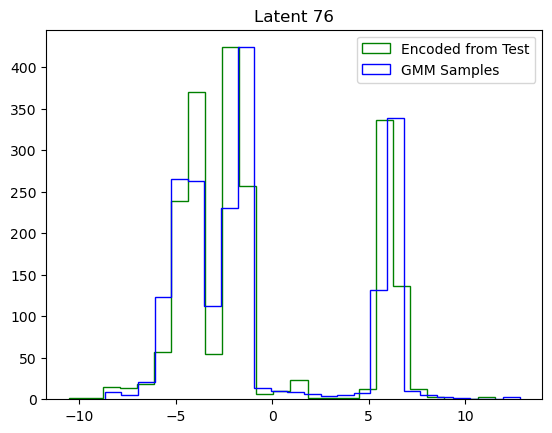

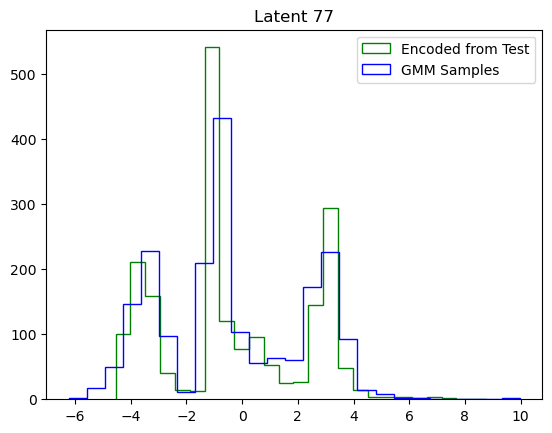

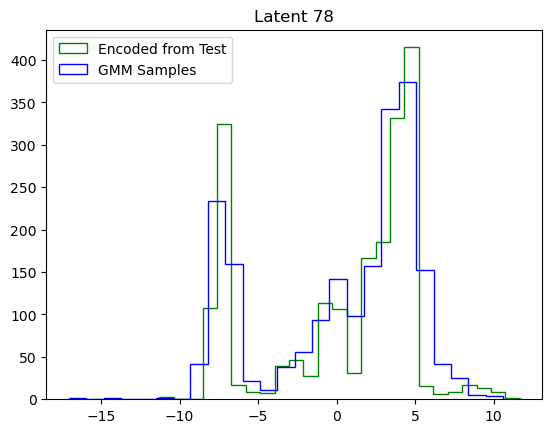

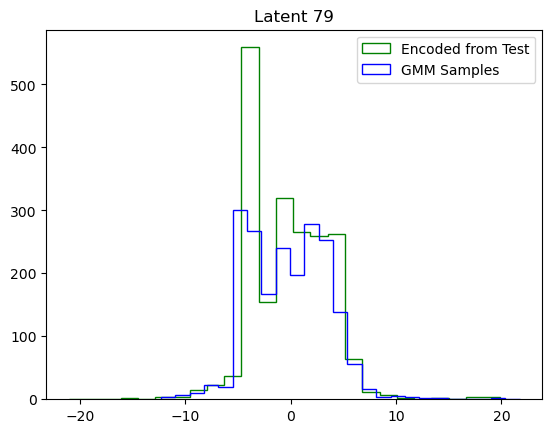

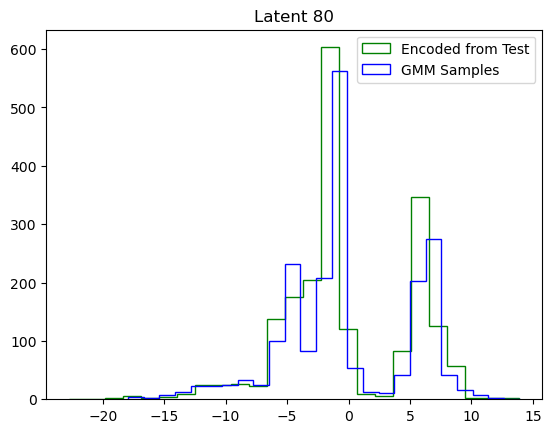

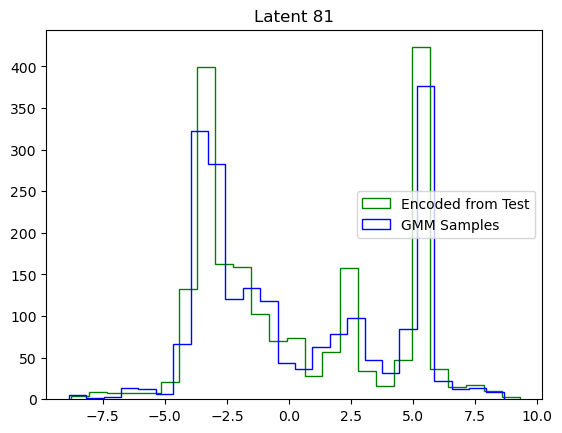

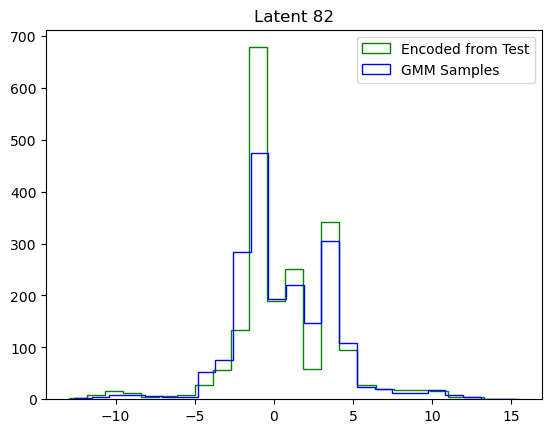

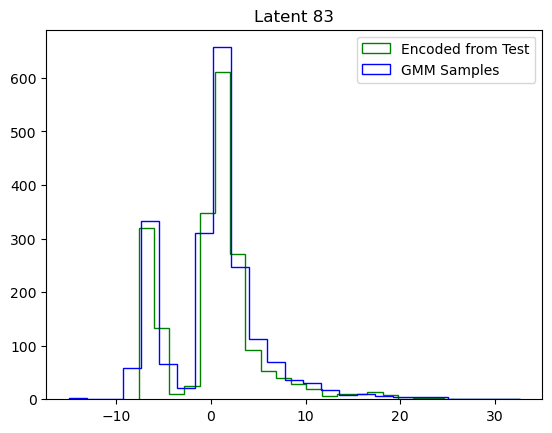

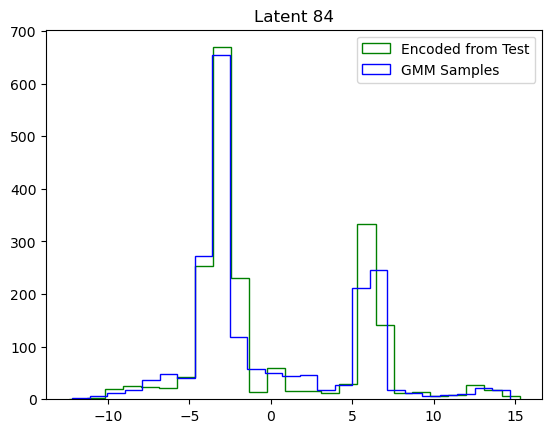

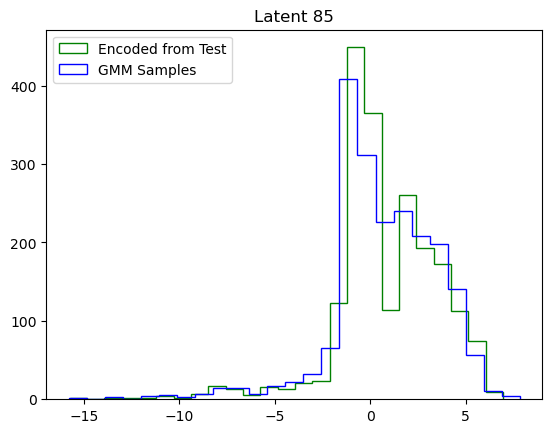

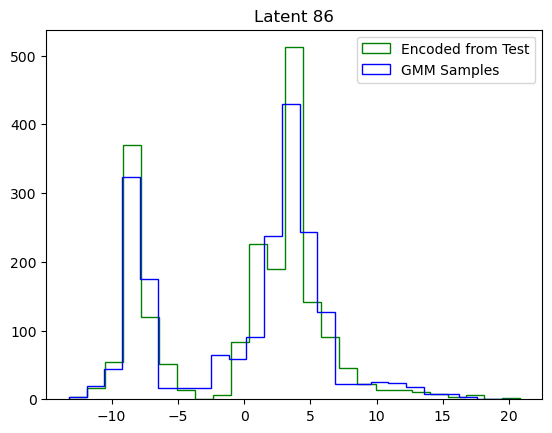

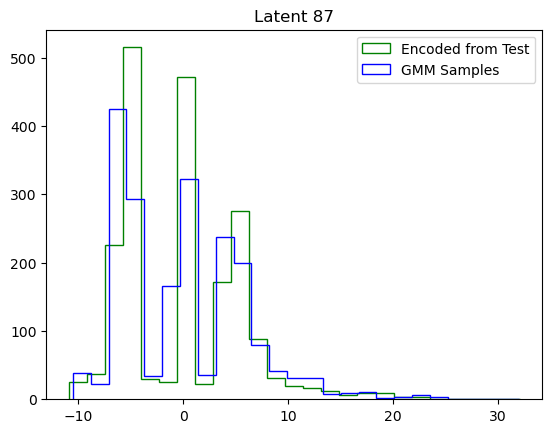

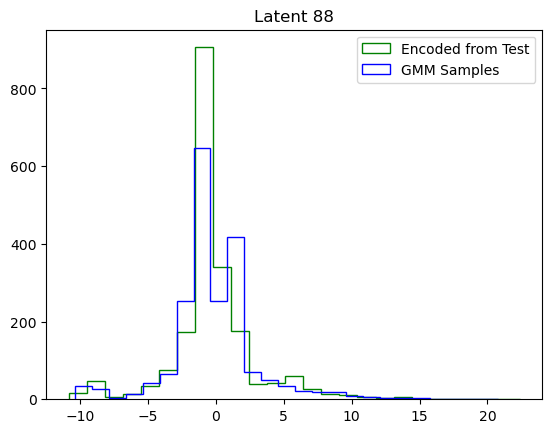

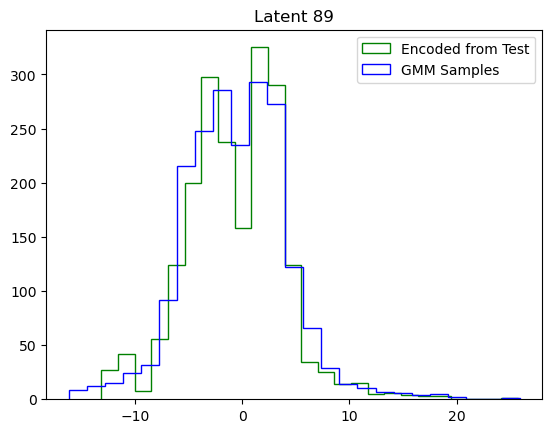

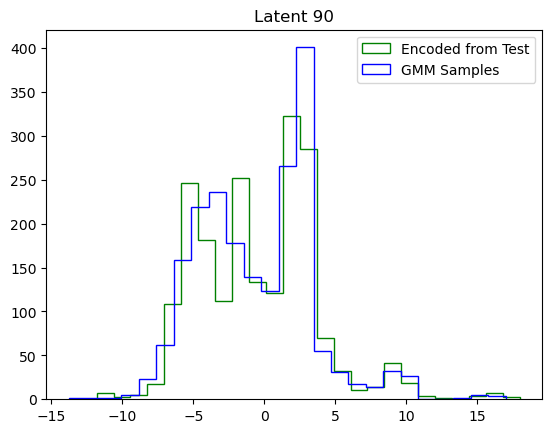

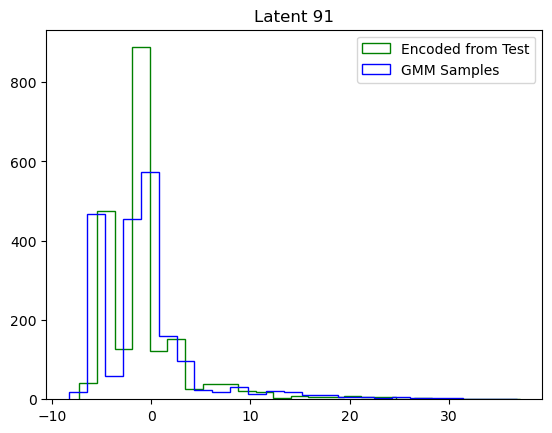

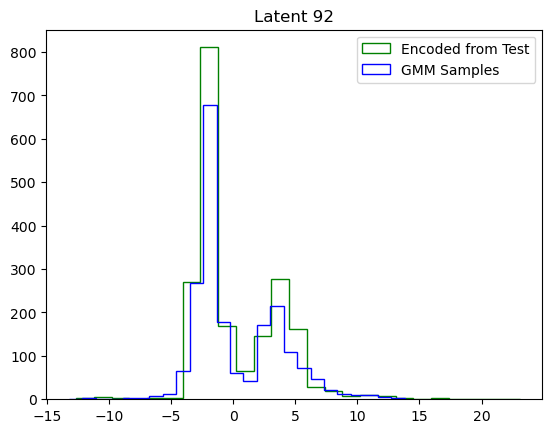

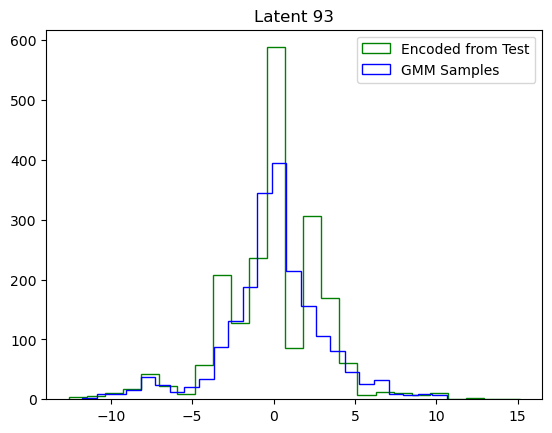

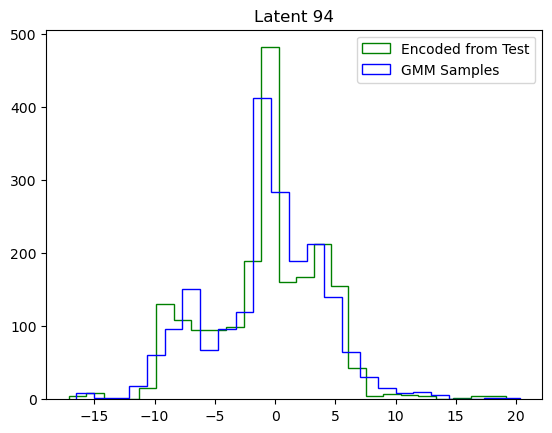

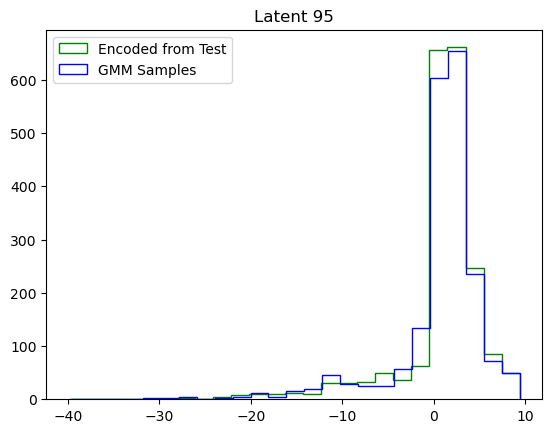

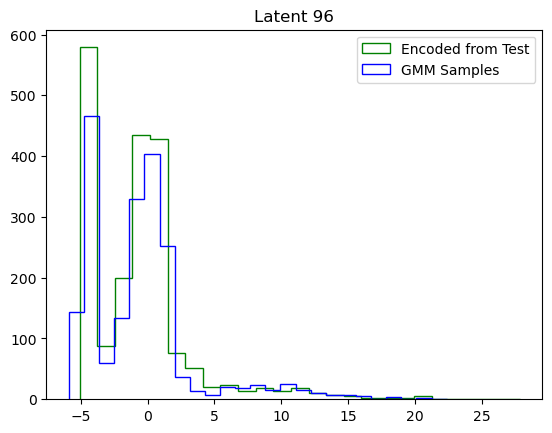

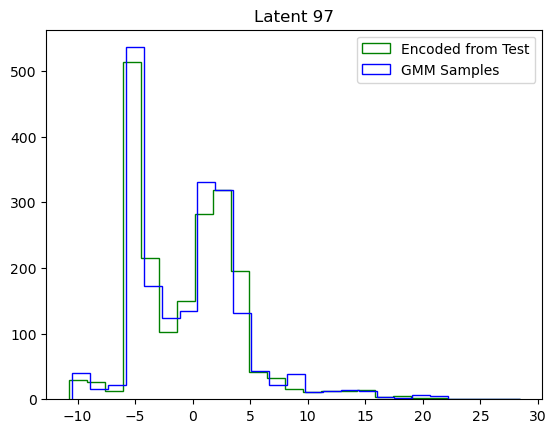

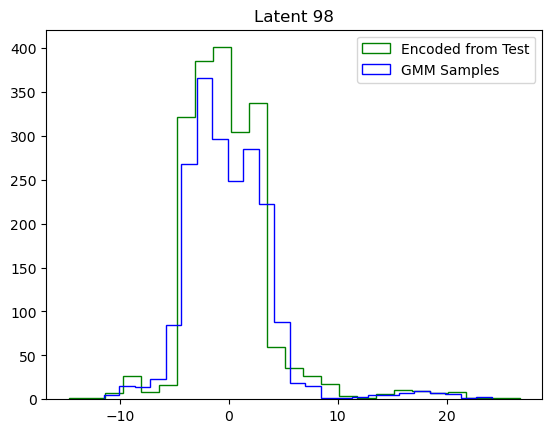

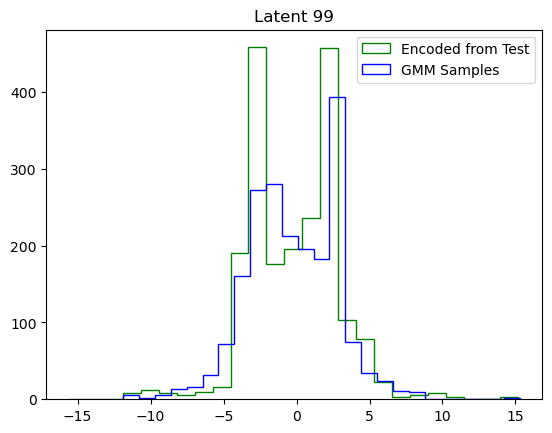

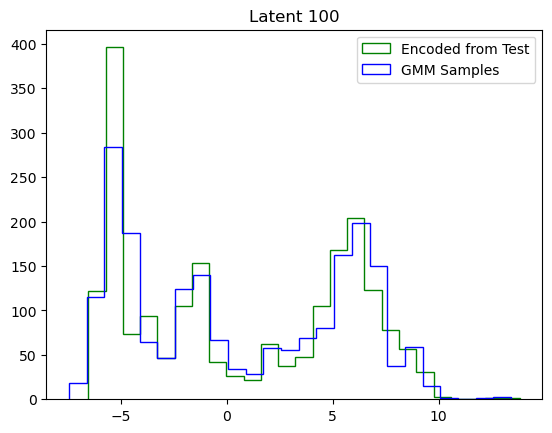

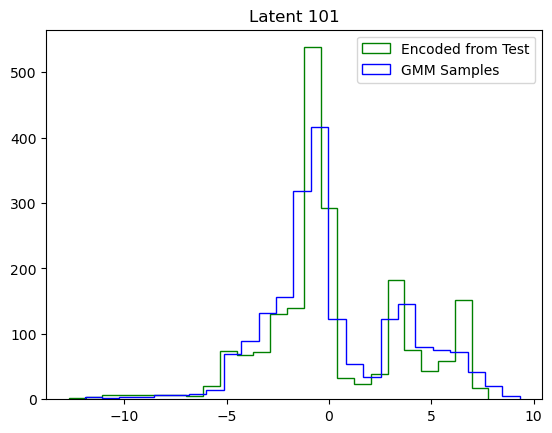

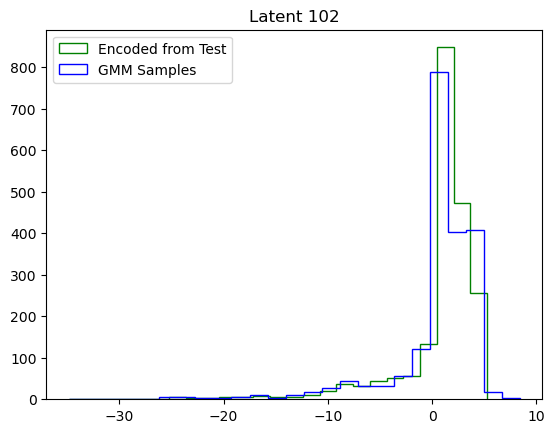

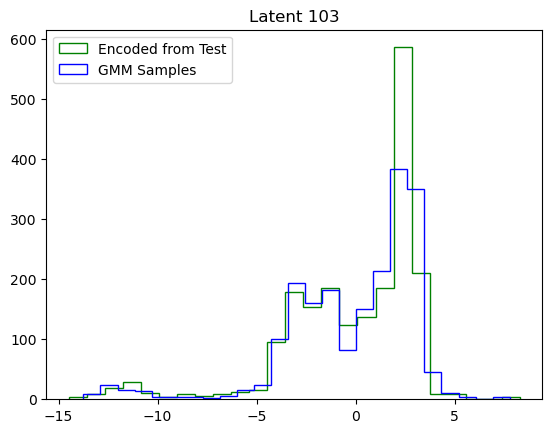

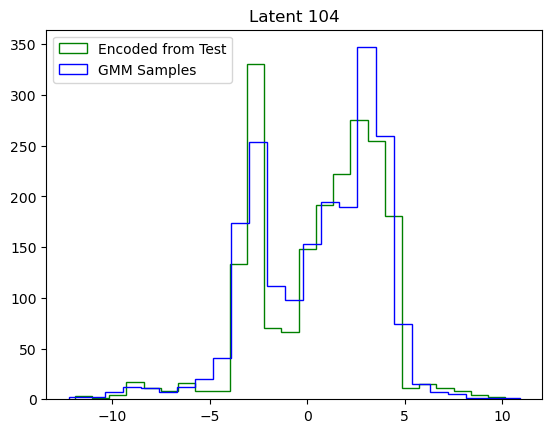

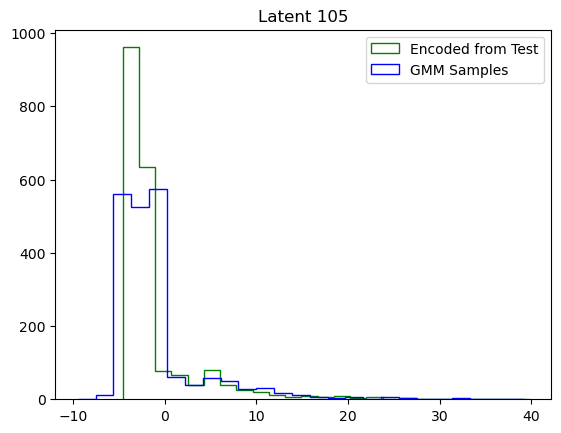

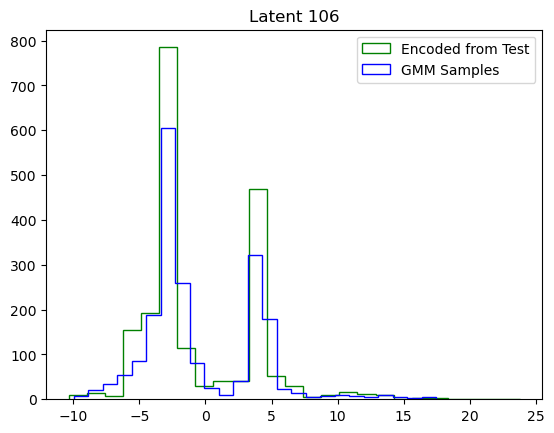

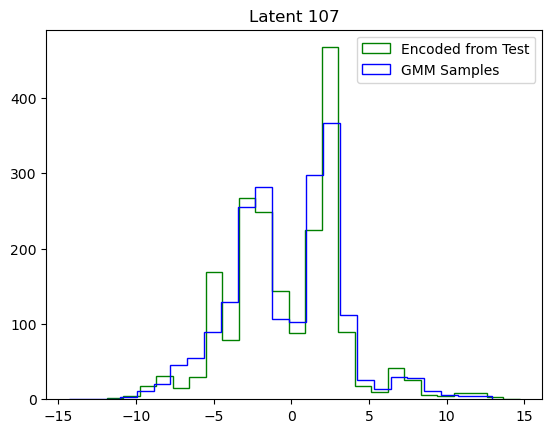

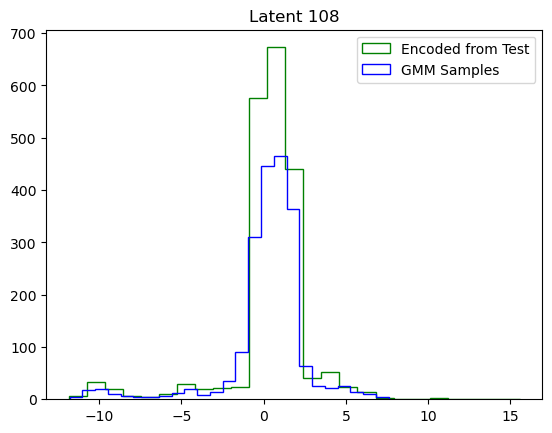

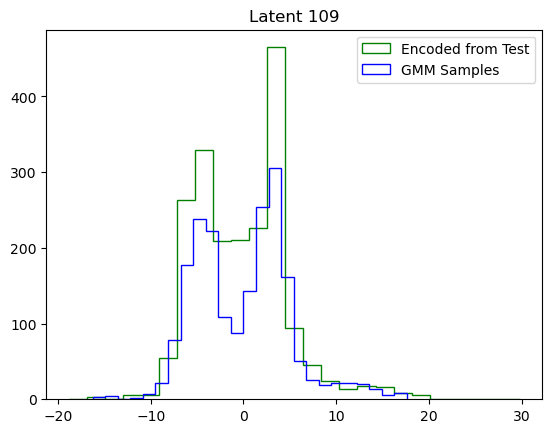

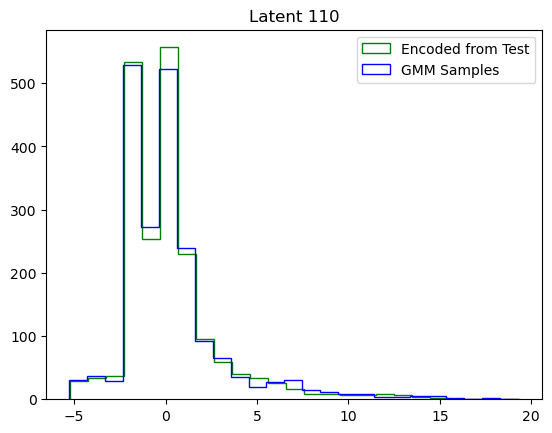

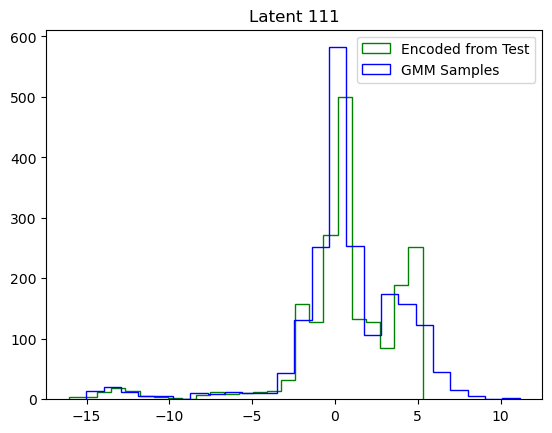

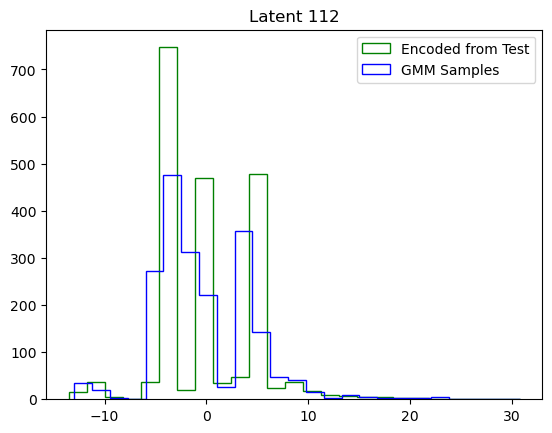

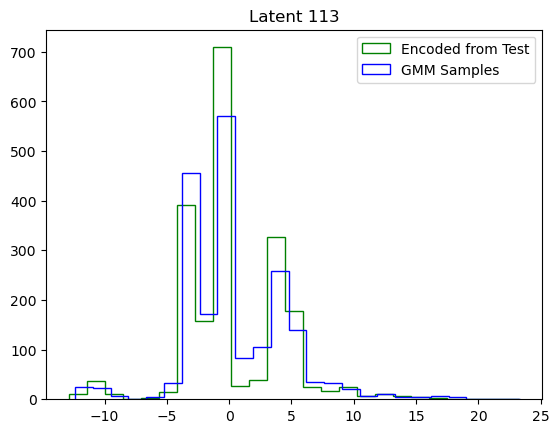

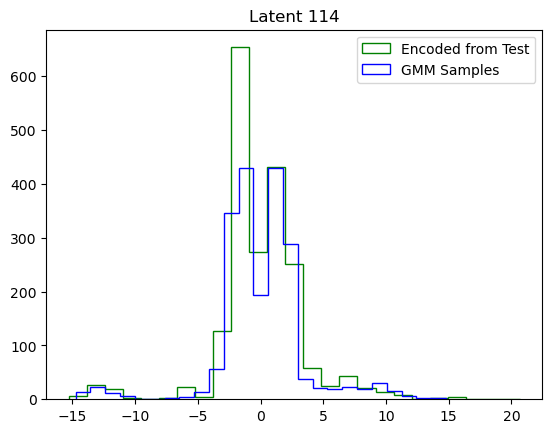

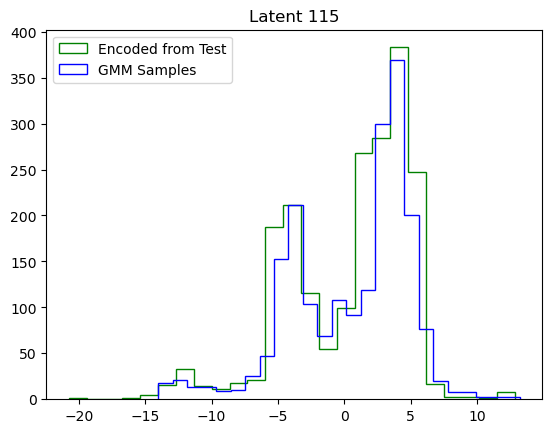

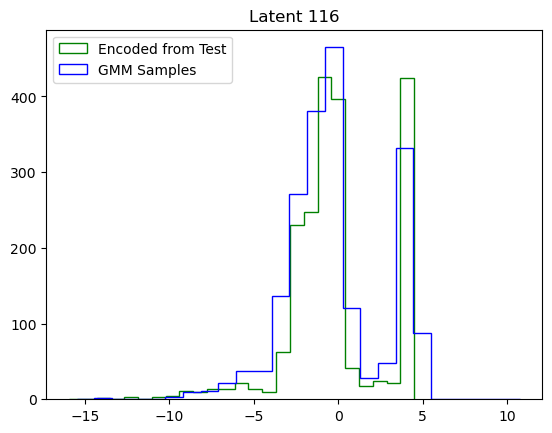

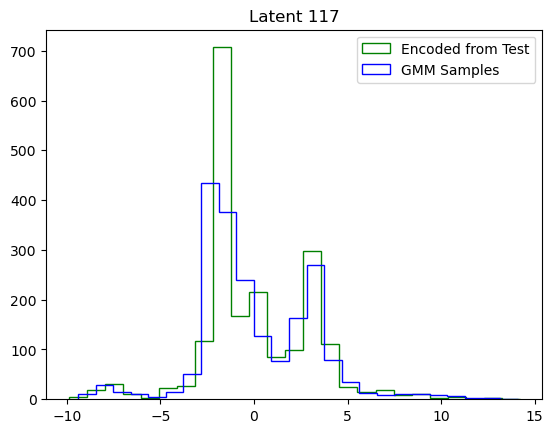

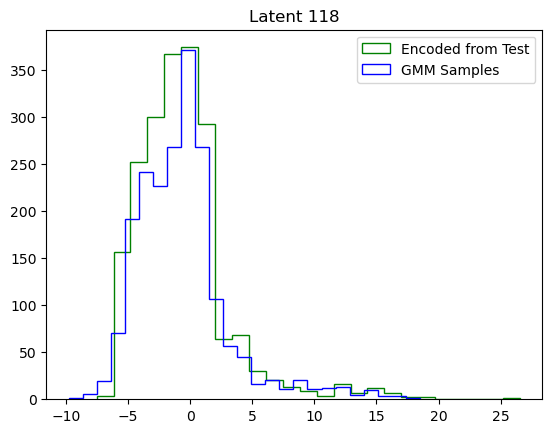

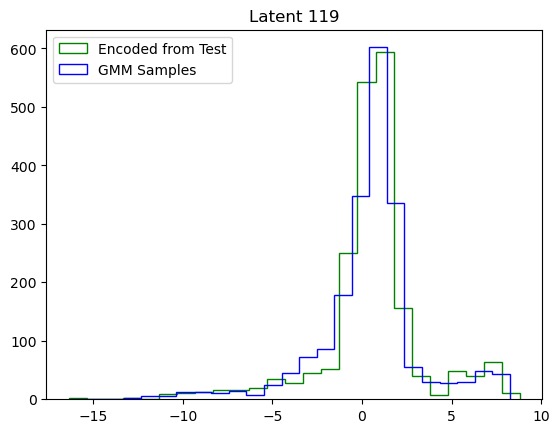

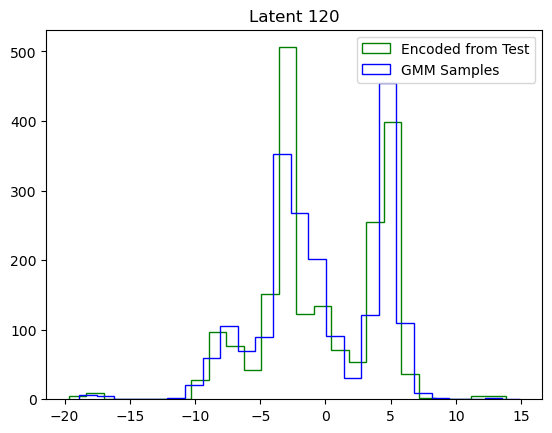

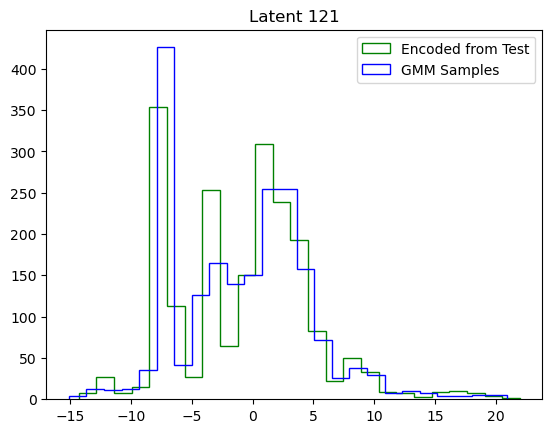

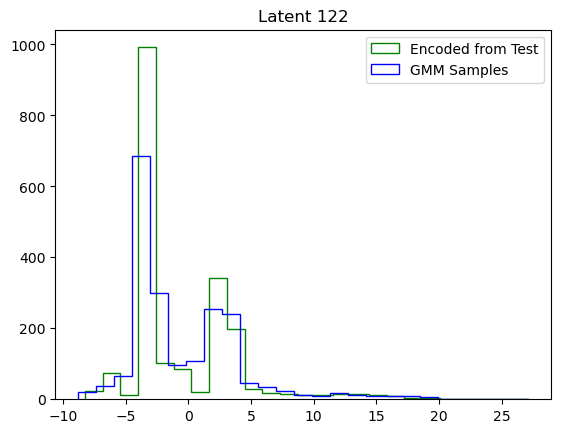

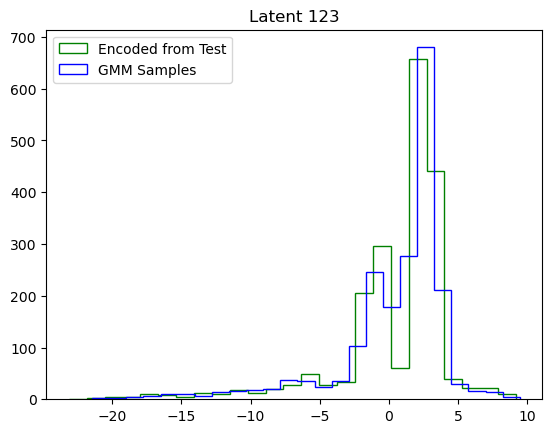

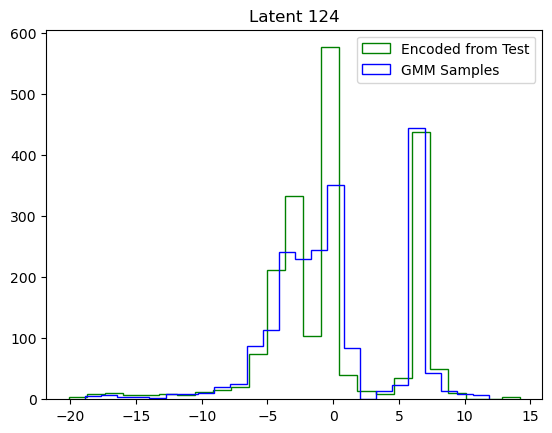

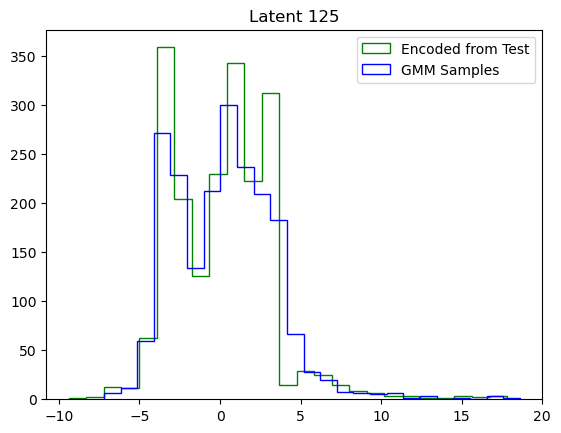

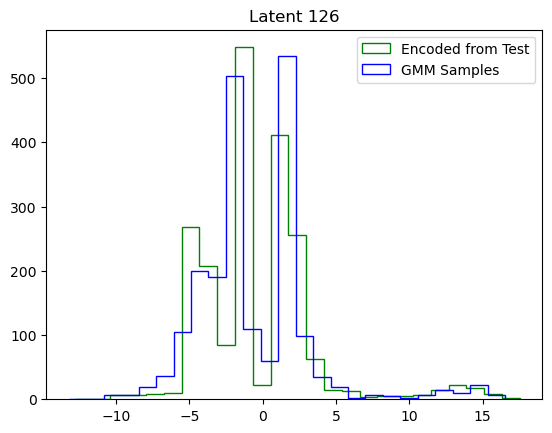

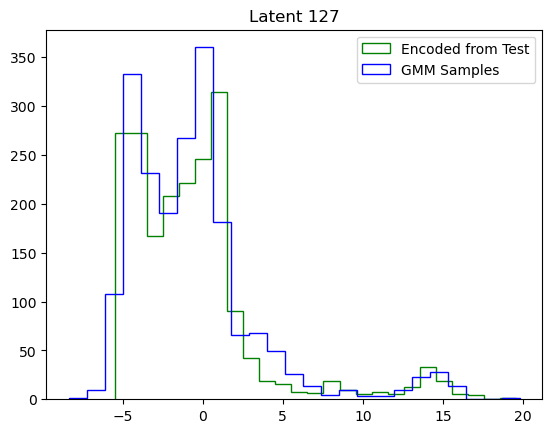

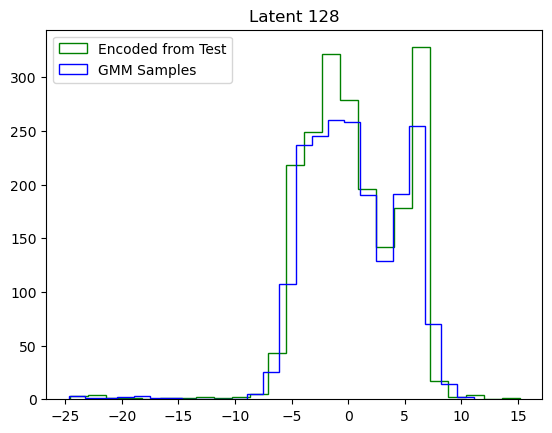

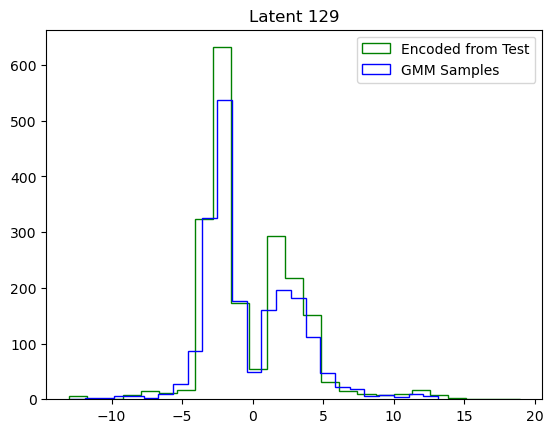

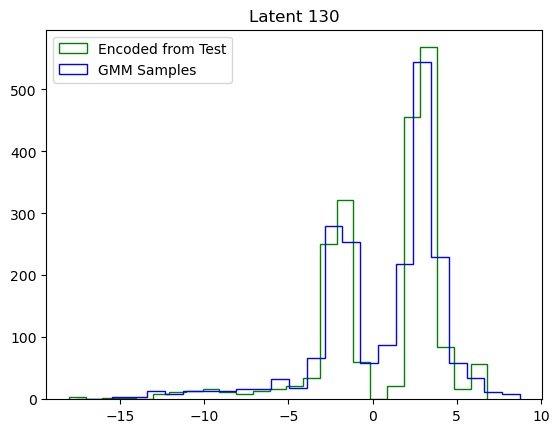

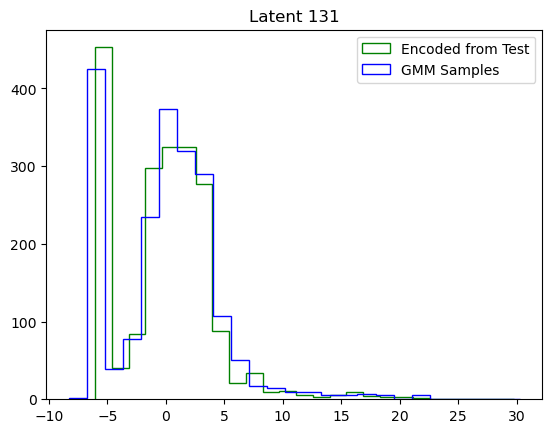

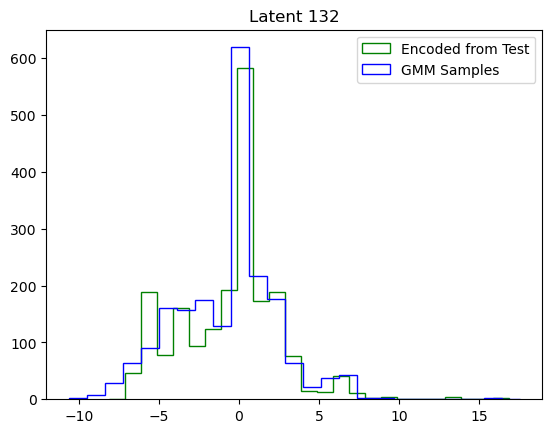

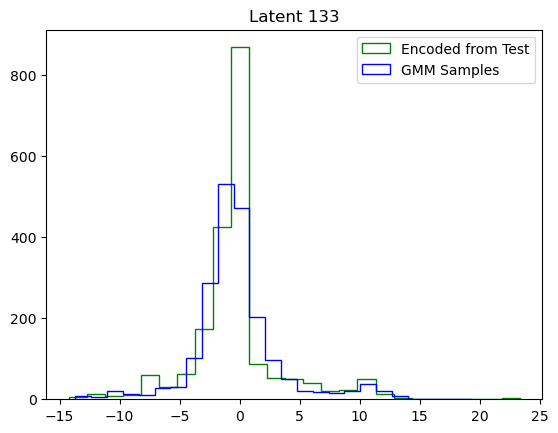

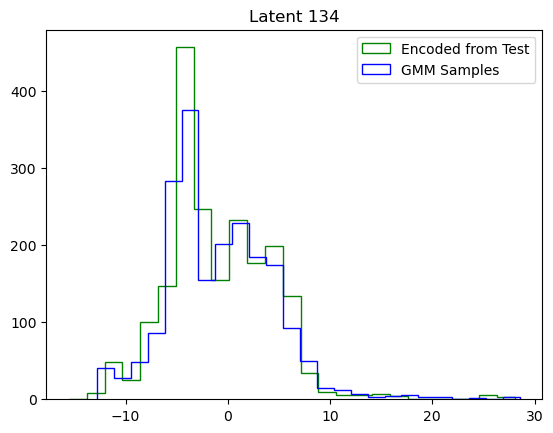

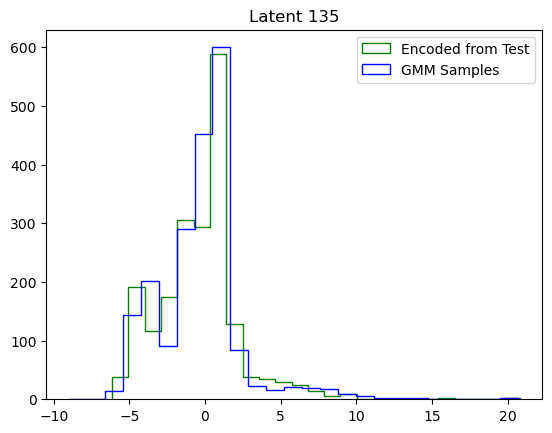

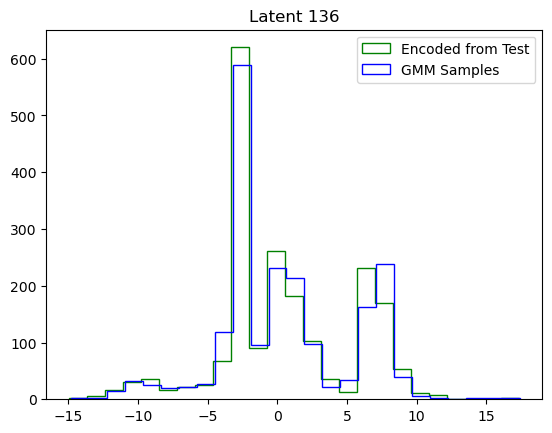

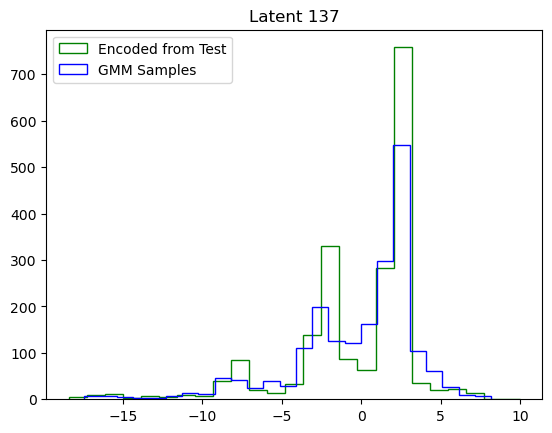

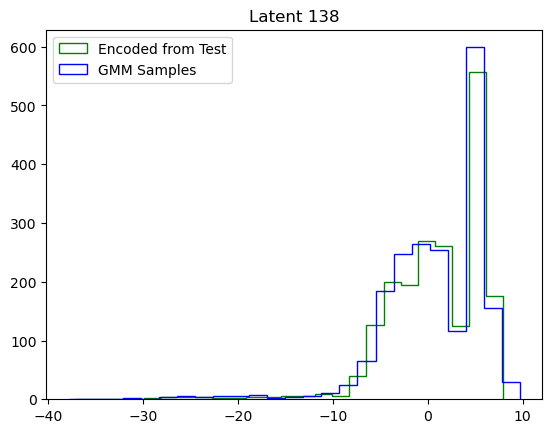

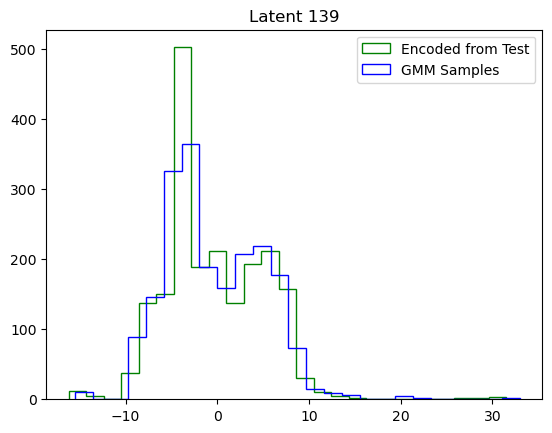

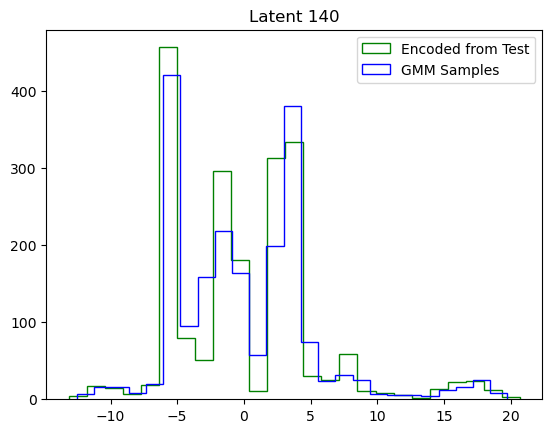

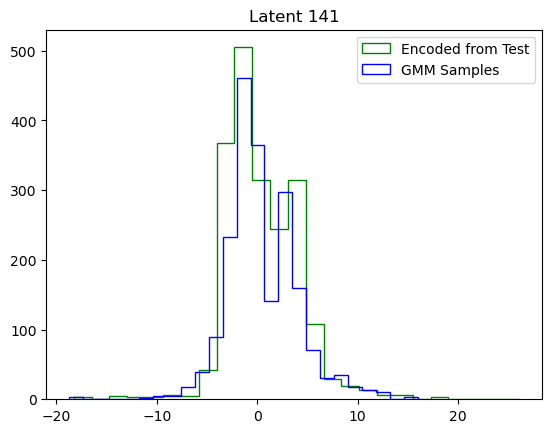

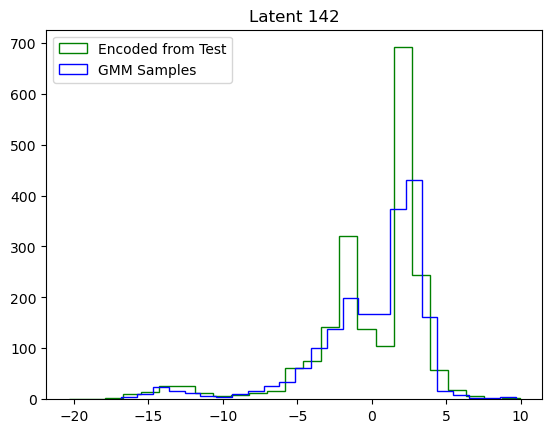

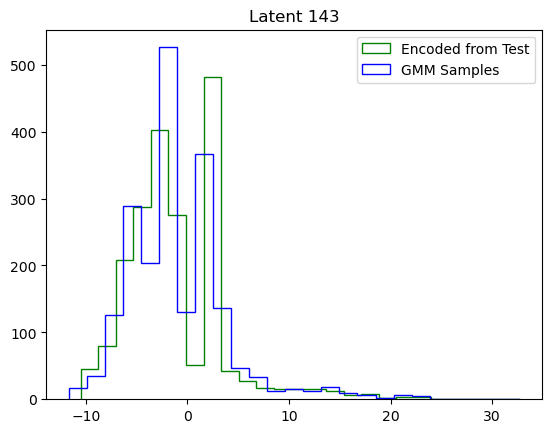

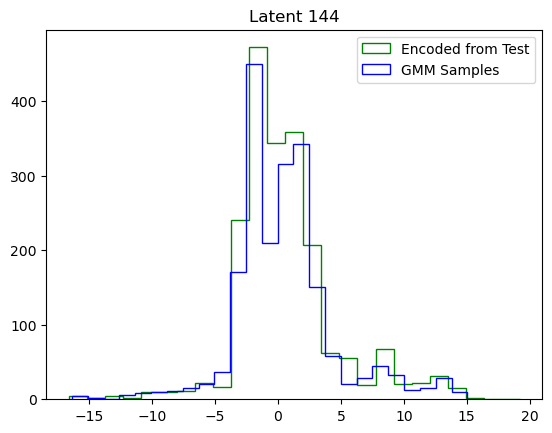

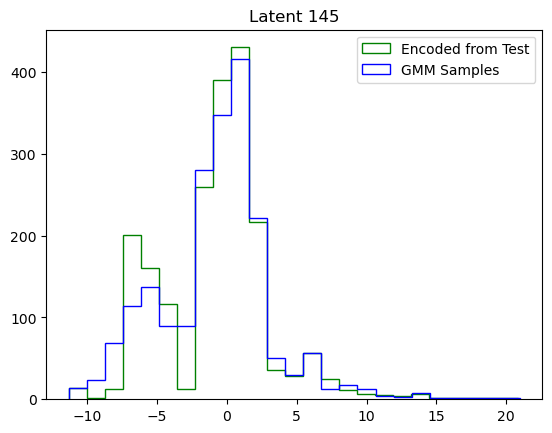

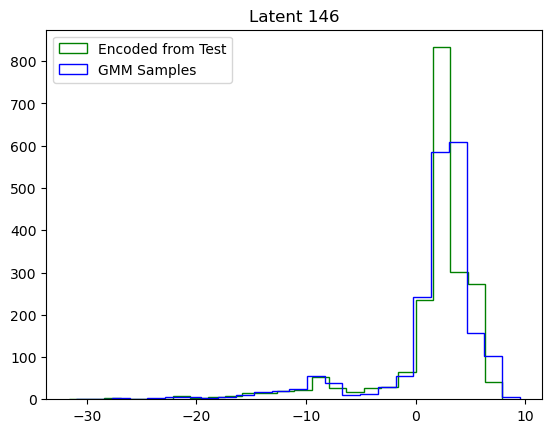

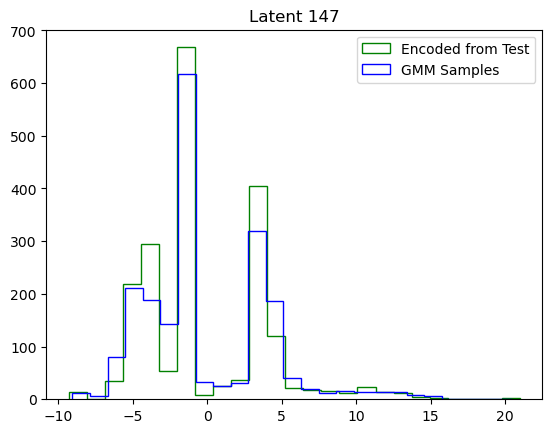

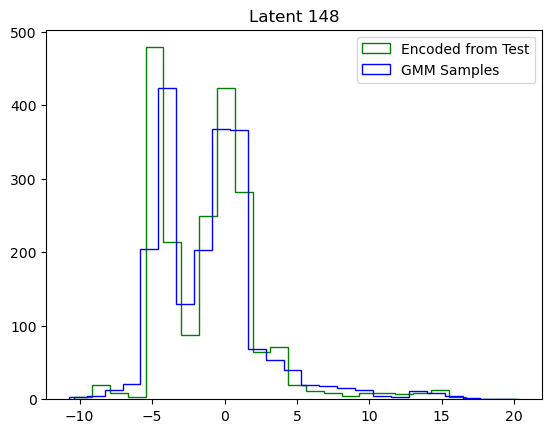

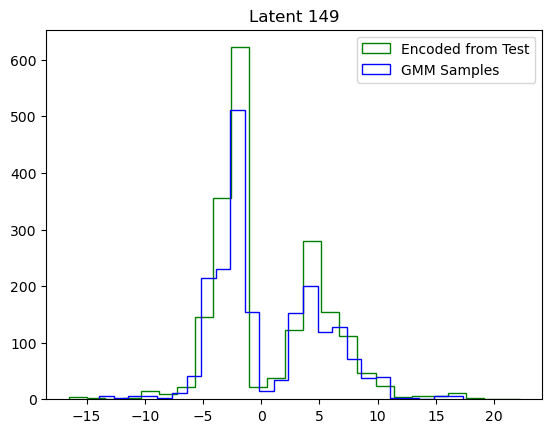

In [13]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latent_means[:,i], bins=25, histtype='step', color='g', label='Encoded from Test')
    _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b', label='GMM Samples')
    plt.title(f'Latent {i}')
    plt.legend()
    plt.show()

In [4]:
from pyscripts.DEV_loss import *

In [5]:
loss_evals = [atom_rmsd, sum1_loss, sum2_loss, sum3_loss, sum4_loss, sum5_loss, sum6_loss, sum7_loss]

In [ ]:
for i in range(len(loss_evals)):
    print(f"Loss function {i}", file=file, flush=True)
    loss_eval = loss_evals[i]
    loss = 1e5
    while loss > 1:
        epoch_start = datetime.now()
        
        #Training
        f = iter(self.train_batches)
        batch_loss = []
        for b in range(self.train_batches.num_batches):
            #Get Batch
            batch = next(f)
            #Train Batch
            root_key = jax.random.PRNGKey(self.epoch)
            main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)
            self.state, loss = step(self.state, batch, root_key, dropout_key, loss_eval)
            batch_loss.append(loss)
        train_loss = np.mean(batch_loss)
        
        #After ANY EPOCH
        save_args = orbax_utils.save_args_from_target(self.state)
        self.checkpoint_manager.save(self.epoch, self.state, save_kwargs={'save_args': save_args})
            
        #After all batches seen this epoch
        epoch_end = datetime.now() - epoch_start
        if self.epoch % 10 == 0:
            recon = self.state.apply_fn({'params':self.state.params, 'batch_stats':self.state.batch_stats}, self.test_data, root_key, train=False, rngs={'dropout': dropout_key})[0]
            test_loss = loss_eval(self.test_data, recon).mean()
            print(f"{self.epoch} - {'%.4E'%train_loss} - {'%.4E'%test_loss} - 'Time:'{epoch_end}", file=file, flush=True)
        
        self.epoch += 1
    #Print the data after this loss converged
    print("#####  END THIS LOSS FUNCTION WITH LOSS #####", file=file, flush=True)
    recon = self.state.apply_fn({'params':self.state.params, 'batch_stats':self.state.batch_stats}, self.test_data, root_key, train=False, rngs={'dropout': dropout_key})[0]
    test_loss = loss_eval(self.test_data, recon).mean()
    print(f"{self.epoch} - {'%.4E'%train_loss} - {'%.4E'%test_loss} - 'Time:'{epoch_end}", file=file, flush=True)
    print("#############################################", file=file, flush=True)

    #Write a structure (fuckitmaybeitsinteresting)
    fname = f"loss_function{i}_ReconTest.dcd"
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        traj_xyz = recon.reshape(recon.shape[0], -1, 3)
        f.write(traj_xyz*10)

In [ ]:
raise Exception('You Shall Not Pass!')

In [ ]:
experiment.MAIN_scale_and_train_potential(n_rmsd=200)

In [ ]:
experiment.train_scaling_potential()

In [ ]:
raise Exception('So you have chosen death...')

In [ ]:
traingrp = experiment.rootgrp['Train']
testgrp = experiment.rootgrp['Test']
scaling_start = np.where(experiment.rootgrp['Train'].variables['Potential Coefficient'][:] == 0)[0][-1]
scaling_end = np.where(experiment.rootgrp['Train'].variables['Potential Coefficient'][:] == 1)[0][0]

In [ ]:
plt.clf()
_ = plt.plot(np.arange(experiment.epoch), np.mean(traingrp['RMSD'][:-1, :], axis=1))
_ = plt.plot(np.arange(experiment.epoch), np.mean(testgrp['RMSD'][:-1, :], axis=1))
plt.legend(['Train', 'Test'])
plt.show()

In [ ]:
key='Potential'
plt.clf()
_ = plt.plot(np.arange(experiment.epoch), np.mean(traingrp[key][:-1, :], axis=1))
_ = plt.plot(np.arange(experiment.epoch), np.mean(testgrp[key][:-1, :], axis=1))
plt.legend(['Train', 'Test'])
plt.yscale('log')
plt.show()

In [ ]:
key='Potential'
plt.clf()
_ = plt.plot(np.arange(10000, experiment.epoch), np.mean(traingrp[key][10000:-1, :], axis=1))
_ = plt.plot(np.arange(10000, experiment.epoch), np.mean(testgrp[key][10000:-1, :], axis=1))
plt.legend(['Train', 'Test'])
plt.yscale('log')
plt.hlines(10, 10000, 30000, colors='red', linestyles='dashed')
plt.show()

In [ ]:
def epoch_would_have_stopped(potential_threshold):
    key = 'Potential'
    num_move_ave = 100
    train_potentials = np.mean(traingrp[key][:-1, :], axis=1)
    test_potentials = np.mean(testgrp[key][:-1, :], axis=1)
    i = 100
    potential_above_threshold, test_potential_decreasing = True, True
    while potential_above_threshold or test_potential_decreasing:
        potential_above_threshold = (train_potentials[i-num_move_ave:i].mean() > potential_threshold or
                                     test_potentials[i-num_move_ave:i].mean() > potential_threshold)
        test_potential_decreasing = test_potentials[i-2*num_move_ave:i-num_move_ave].mean() > test_potentials[i-num_move_ave:i].mean()
        i += 1
    return i

In [ ]:
experiment.epoch

In [ ]:
epoch_would_have_stopped(10)

In [ ]:
key='Potential'
plt.clf()
_ = plt.plot(np.arange(10000, experiment.epoch), np.mean(traingrp[key][10000:-1, :], axis=1))
_ = plt.plot(np.arange(10000, experiment.epoch), np.mean(testgrp[key][10000:-1, :], axis=1))
plt.legend(['Train', 'Test'])
plt.yscale('log')
plt.hlines(10, 10000, 30000, colors='red', linestyles='dashed')
plt.vlines(epoch_would_have_stopped(10), 1, 1000, colors='red', linestyles='dashed')
plt.show()

In [ ]:
#Attempt to resume a Bridges2 run with potential scaling

In [ ]:
rng = jax.random.PRNGKey(experiment.epoch)
rng, key = jax.random.split(rng)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

fig, axs = plt.subplots(experiment.n_latents, experiment.n_latents, figsize=(15,10), sharex='col')
for i in range(experiment.n_latents):
    for j in range(experiment.n_latents):
        #axs[i,j].scatter(latent[:,j], latent[:,i])
        if i > j:
            axs[i,j].scatter(latents[:,j], latents[:,i])
        elif i == j:
            axs[i,j].hist(latents[:, i], bins=25)

In [ ]:
print(experiment.rootgrp)
print(experiment.rootgrp['Train'])
print(experiment.rootgrp['Test'])

In [ ]:
plt.clf()
_ = plt.plot(np.arange(rmsd_train.shape[0]), rmsd_train)
_ = plt.plot(np.arange(rmsd_test.shape[0]), rmsd_test)
plt.legend(['Train', 'Test'])
plt.ylim(0.14, .15)
plt.show()

In [ ]:
rmsd_train = np.mean(experiment.rootgrp['Train'].variables['RMSD'], axis=1)
rmsd_test = np.mean(experiment.rootgrp['Test'].variables['RMSD'], axis=1)
d_tt = np.sqrt((rmsd_test - rmsd_train)**2)/rmsd_train * 100

In [ ]:
plt.clf()
_ = plt.plot(np.arange(d_tt.shape[0]), d_tt)
plt.xlabel('Epoch')
plt.ylabel('Deviation (Percentage)')
plt.title('Percent Deviation of Test Loss from Train Loss')
plt.show()

In [ ]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
test_data = experiment.test_data
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, test_data, rng)

In [ ]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture
ics = []
for i in range(1, 50):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()
print(f'minimums: Akaike {np.argmin(ics[:,1]) + 1} Bayes {np.argmin(ics[:,2]) + 1}')

In [ ]:
X = np.array(latents)
MM = GaussianMixture(n_components=2).fit(X) #chosen based on above graph
samples = MM.sample(2000)[0]

In [ ]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

In [ ]:
import scipy
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
        print(i, j, scipy.stats.pearsonr(latents[:,j], latents[:,i]))
fig.savefig('7L.png', dpi=600)

In [ ]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=300, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=300, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

In [ ]:
def write_traj(filename, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    with md.formats.DCDTrajectoryFile(filename, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but saves it in angstrom

my_dict = {'DA_TestData.dcd' : experiment.test_data, 'DA_ReconData.dcd' : recon, 'DA_GMM.dcd' : decoded_samples}
for key, value in zip(my_dict.keys(), my_dict.values()):
    write_traj(key, value)

In [ ]:
rmsds = atom_rmsd(experiment.test_data, recon)
plt.clf()
_ = plt.hist(rmsds, bins=100)
plt.show()
# ener_comp = scaled_pot_enr_diff(experiment.test_data, recon)
# plt.clf()
# _ = plt.hist(ener_comp[ener_comp < 5], bins=100)
# plt.show()

In [ ]:
recon_train , _ = experiment.state.apply_fn({'params':experiment.state.params}, experiment.train_data, rng)
my_dict = {'DA_TrainData.dcd' : experiment.train_data, 'DA_ReconData_train.dcd' : recon_train}
for key, value in zip(my_dict.keys(), my_dict.values()):
    write_traj(key, value)